# Q1 Uncertainty Report: Bootstrap Certainty Analysis\n\nThis notebook analyzes bootstrap uncertainty metrics for DWTS voting predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
import warnings

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
np.set_printoptions(precision=4)

OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
DATA_PATH = './data/q1_bootstrap_uncertainty.csv'

REQUIRED_COLS = [
    'season', 'week', 'celebrity_name',
    'pV_mean', 'pV_median', 'pV_std', 'pV_cv',
    'pV_ci_2.5', 'pV_ci_97.5', 'pV_ci_95_width',
    'n_bootstrap_samples', 'rule_type', 'pV_hat',
    'elim_prob', 'eliminated_end_of_week'
]

print("Output directory:", OUTPUT_DIR.absolute())

Matplotlib is building the font cache; this may take a moment.


Output directory: /Users/luoyiti/Project/Archiving/MCM_2026/outputs


## 1. Data Loading and Quality Checks

In [2]:
def load_data(path: str) -> pd.DataFrame:
    """Load and validate the bootstrap uncertainty CSV."""
    df = pd.read_csv(path)
    
    # Check required columns
    missing = set(REQUIRED_COLS) - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # Type conversions
    df['season'] = df['season'].astype(int)
    df['week'] = df['week'].astype(int)
    df['eliminated_end_of_week'] = df['eliminated_end_of_week'].astype(bool)
    
    print(f"Loaded {len(df)} rows, {df['season'].nunique()} seasons, {df['celebrity_name'].nunique()} contestants")
    return df

def check_data_quality(df: pd.DataFrame) -> pd.DataFrame:
    """Run data quality checks and return cleaned DataFrame."""
    
    # Check pV_mean sums to ~1 per (season, week)
    pv_sums = df.groupby(['season', 'week'])['pV_mean'].sum()
    deviations = (pv_sums - 1.0).abs()
    bad_sums = deviations[deviations > 1e-6].sort_values(ascending=False)
    
    if len(bad_sums) > 0:
        print(f"WARNING: {len(bad_sums)} (season,week) groups have pV_mean sum != 1")
        print("Top 5 deviations:")
        print(bad_sums.head().to_frame('deviation'))
    else:
        print("✓ All (season,week) pV_mean sums are valid (within 1e-6 of 1.0)")
    
    # Check duplicates
    dup_mask = df.duplicated(subset=['season', 'week', 'celebrity_name'], keep='first')
    n_dups = dup_mask.sum()
    if n_dups > 0:
        print(f"WARNING: {n_dups} duplicate (season,week,celebrity_name) rows found, keeping first")
        df = df[~dup_mask].copy()
    else:
        print("✓ No duplicate rows found")
    
    return df

# Load and validate
df = load_data(DATA_PATH)
df = check_data_quality(df)
print(f"\nFinal dataset: {len(df)} observations")

Loaded 2777 rows, 34 seasons, 408 contestants
✓ All (season,week) pV_mean sums are valid (within 1e-6 of 1.0)
✓ No duplicate rows found

Final dataset: 2777 observations


## 2. Overall Summary Statistics

In [3]:
def summarize_overall(df: pd.DataFrame) -> dict:
    """Compute global certainty statistics."""
    stats = {
        'n_obs': len(df),
        'n_seasons': df['season'].nunique(),
        'n_weeks': df['week'].nunique(),
        'n_contestants': df['celebrity_name'].nunique(),
        
        # CI width statistics
        'ci_width_mean': df['pV_ci_95_width'].mean(),
        'ci_width_median': df['pV_ci_95_width'].median(),
        'ci_width_std': df['pV_ci_95_width'].std(),
        'ci_width_p10': df['pV_ci_95_width'].quantile(0.10),
        'ci_width_p25': df['pV_ci_95_width'].quantile(0.25),
        'ci_width_p75': df['pV_ci_95_width'].quantile(0.75),
        'ci_width_p90': df['pV_ci_95_width'].quantile(0.90),
        'ci_width_iqr': df['pV_ci_95_width'].quantile(0.75) - df['pV_ci_95_width'].quantile(0.25),
        'ci_width_p90_p10_ratio': df['pV_ci_95_width'].quantile(0.90) / df['pV_ci_95_width'].quantile(0.10),
        
        # CV statistics
        'cv_mean': df['pV_cv'].mean(),
        'cv_median': df['pV_cv'].median(),
        'cv_std': df['pV_cv'].std(),
        'cv_p10': df['pV_cv'].quantile(0.10),
        'cv_p25': df['pV_cv'].quantile(0.25),
        'cv_p75': df['pV_cv'].quantile(0.75),
        'cv_p90': df['pV_cv'].quantile(0.90),
        'cv_iqr': df['pV_cv'].quantile(0.75) - df['pV_cv'].quantile(0.25),
        'cv_p90_p10_ratio': df['pV_cv'].quantile(0.90) / df['pV_cv'].quantile(0.10),
        
        # Bootstrap samples
        'bootstrap_B_min': int(df['n_bootstrap_samples'].min()),
        'bootstrap_B_max': int(df['n_bootstrap_samples'].max()),
        'bootstrap_B_median': float(df['n_bootstrap_samples'].median()),
        'bootstrap_B_mean': df['n_bootstrap_samples'].mean(),
    }
    return stats

overall_stats = summarize_overall(df)

# Display as DataFrame for readability
overall_df = pd.DataFrame([overall_stats]).T
overall_df.columns = ['Value']
print("="*60)
print("OVERALL CERTAINTY STATISTICS")
print("="*60)
display(overall_df)

OVERALL CERTAINTY STATISTICS


,Value
n_obs,2777.0000
n_seasons,34.0000
n_weeks,11.0000
n_contestants,408.0000
ci_width_mean,0.0360
ci_width_median,0.0314
ci_width_std,0.0259
ci_width_p10,0.0056
ci_width_p25,0.0159
ci_width_p75,0.0498


In [4]:
# Season-level bootstrap B analysis
def analyze_bootstrap_by_season(df: pd.DataFrame) -> pd.DataFrame:
    """Check if bootstrap B is constant within each season."""
    season_B = df.groupby('season')['n_bootstrap_samples'].agg(['min', 'max', 'mean', 'std', 'nunique'])
    season_B['is_constant'] = season_B['nunique'] == 1
    return season_B

season_bootstrap_df = analyze_bootstrap_by_season(df)
print("Bootstrap samples by season:")
display(season_bootstrap_df)

all_constant = season_bootstrap_df['is_constant'].all()
print(f"\n→ Bootstrap B is {'CONSTANT' if all_constant else 'NOT constant'} within each season")

Bootstrap samples by season:


,min,max,mean,std,nunique,is_constant
season,,,,,,
1,101,101,101.0000,0.0000,1,True
2,112,112,112.0000,0.0000,1,True
3,99,99,99.0000,0.0000,1,True
4,90,90,90.0000,0.0000,1,True
5,111,111,111.0000,0.0000,1,True
6,101,101,101.0000,0.0000,1,True
7,97,97,97.0000,0.0000,1,True
8,102,102,102.0000,0.0000,1,True
9,100,100,100.0000,0.0000,1,True



→ Bootstrap B is CONSTANT within each season


## 3. Dimension-wise Aggregations

In [5]:
def summarize_by_week(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate uncertainty metrics by week."""
    agg = df.groupby('week').agg({
        'pV_ci_95_width': ['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
        'pV_cv': ['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
        'celebrity_name': 'count'
    })
    agg.columns = ['ci_width_mean', 'ci_width_median', 'ci_width_std', 'ci_width_p25', 'ci_width_p75',
                   'cv_mean', 'cv_median', 'cv_std', 'cv_p25', 'cv_p75', 'n_obs']
    agg['ci_width_iqr'] = agg['ci_width_p75'] - agg['ci_width_p25']
    agg['cv_iqr'] = agg['cv_p75'] - agg['cv_p25']
    return agg.reset_index()

def summarize_by_contestant(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate uncertainty metrics by contestant."""
    agg = df.groupby('celebrity_name').agg({
        'pV_ci_95_width': ['mean', 'median', 'std'],
        'pV_cv': ['mean', 'median', 'std'],
        'season': 'first',
        'week': 'count'
    })
    agg.columns = ['ci_width_mean', 'ci_width_median', 'ci_width_std',
                   'cv_mean', 'cv_median', 'cv_std', 'season', 'n_obs']
    return agg.reset_index()

def summarize_by_rule(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate uncertainty metrics by rule_type."""
    agg = df.groupby('rule_type').agg({
        'pV_ci_95_width': ['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
        'pV_cv': ['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)],
        'celebrity_name': 'count'
    })
    agg.columns = ['ci_width_mean', 'ci_width_median', 'ci_width_std', 'ci_width_p25', 'ci_width_p75',
                   'cv_mean', 'cv_median', 'cv_std', 'cv_p25', 'cv_p75', 'n_obs']
    return agg.reset_index()

def summarize_by_elimination(df: pd.DataFrame) -> pd.DataFrame:
    """Compare eliminated vs non-eliminated contestants."""
    agg = df.groupby('eliminated_end_of_week').agg({
        'pV_ci_95_width': ['mean', 'median', 'std'],
        'pV_cv': ['mean', 'median', 'std'],
        'celebrity_name': 'count'
    })
    agg.columns = ['ci_width_mean', 'ci_width_median', 'ci_width_std',
                   'cv_mean', 'cv_median', 'cv_std', 'n_obs']
    agg.index = agg.index.map({True: 'Eliminated', False: 'Not Eliminated'})
    return agg.reset_index().rename(columns={'eliminated_end_of_week': 'status'})

def summarize_by_share_quartile(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate by pV_mean quartiles."""
    df = df.copy()
    df['share_quartile'] = pd.qcut(df['pV_mean'], 4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
    agg = df.groupby('share_quartile', observed=True).agg({
        'pV_mean': 'mean',
        'pV_ci_95_width': ['mean', 'median'],
        'pV_cv': ['mean', 'median'],
        'celebrity_name': 'count'
    })
    agg.columns = ['pV_mean_avg', 'ci_width_mean', 'ci_width_median', 'cv_mean', 'cv_median', 'n_obs']
    return agg.reset_index()

# Compute all aggregations
by_week_df = summarize_by_week(df)
by_contestant_df = summarize_by_contestant(df)
by_rule_df = summarize_by_rule(df)
by_elimination_df = summarize_by_elimination(df)
by_share_quartile_df = summarize_by_share_quartile(df)

print("Aggregations computed successfully.")

Aggregations computed successfully.


In [6]:
print("="*60)
print("BY WEEK AGGREGATION")
print("="*60)
display(by_week_df)

print("\n" + "="*60)
print("BY RULE TYPE AGGREGATION")
print("="*60)
display(by_rule_df)

print("\n" + "="*60)
print("BY ELIMINATION STATUS")
print("="*60)
display(by_elimination_df)

print("\n" + "="*60)
print("BY SHARE QUARTILE (pV_mean)")
print("="*60)
display(by_share_quartile_df)

BY WEEK AGGREGATION


,week,ci_width_mean,ci_width_median,ci_width_std,ci_width_p25,ci_width_p75,cv_mean,cv_median,cv_std,cv_p25,cv_p75,n_obs,ci_width_iqr,cv_iqr
0,1,0.0251,0.0273,0.0105,0.0159,0.0327,0.0814,0.0924,0.0290,0.0521,0.1011,421,0.0167,0.0490
1,2,0.0261,0.0275,0.0148,0.0141,0.0374,0.0802,0.0939,0.0375,0.0489,0.1071,404,0.0233,0.0582
2,3,0.0292,0.0308,0.0177,0.0129,0.0437,0.0798,0.0943,0.0394,0.0385,0.1096,360,0.0307,0.0711
3,4,0.0320,0.0325,0.0207,0.0105,0.0492,0.0792,0.0931,0.0401,0.0329,0.1095,326,0.0388,0.0766
4,5,0.0348,0.0321,0.0222,0.0111,0.0554,0.0780,0.0951,0.0393,0.0309,0.1071,288,0.0443,0.0762
5,6,0.0377,0.0329,0.0245,0.0140,0.0601,0.0775,0.0930,0.0375,0.0352,0.1039,261,0.0460,0.0688
6,7,0.0410,0.0359,0.0272,0.0134,0.0659,0.0756,0.0918,0.0375,0.0314,0.1004,228,0.0525,0.0689
7,8,0.0481,0.0439,0.0314,0.0218,0.0771,0.0737,0.0891,0.0370,0.0333,0.0978,191,0.0553,0.0645
8,9,0.0585,0.0694,0.0361,0.0216,0.0909,0.0733,0.0876,0.0349,0.0465,0.0962,152,0.0693,0.0497
9,10,0.0752,0.0873,0.0399,0.0322,0.1062,0.0710,0.0839,0.0308,0.0353,0.0925,109,0.0740,0.0572



BY RULE TYPE AGGREGATION


,rule_type,ci_width_mean,ci_width_median,ci_width_std,ci_width_p25,ci_width_p75,cv_mean,cv_median,cv_std,cv_p25,cv_p75,n_obs
0,R1_Rank,0.0188,0.0151,0.0131,0.0092,0.0245,0.0284,0.0264,0.0159,0.0153,0.0346,78
1,R2_Percent,0.0462,0.0393,0.0230,0.0292,0.0587,0.0994,0.0984,0.0126,0.0902,0.1080,1997
2,R3_Bottom2,0.0087,0.0067,0.0070,0.0045,0.0100,0.0225,0.0178,0.0128,0.0124,0.0316,702



BY ELIMINATION STATUS


,status,ci_width_mean,ci_width_median,ci_width_std,cv_mean,cv_median,cv_std,n_obs
0,Not Eliminated,0.0375,0.0334,0.0267,0.0780,0.0930,0.0377,2484
1,Eliminated,0.0227,0.0208,0.0100,0.0779,0.0876,0.0265,293



BY SHARE QUARTILE (pV_mean)


,share_quartile,pV_mean_avg,ci_width_mean,ci_width_median,cv_mean,cv_median,n_obs
0,Q1 (lowest),0.0687,0.0180,0.0206,0.0697,0.0855,695
1,Q2,0.0881,0.0273,0.0310,0.0820,0.0948,694
2,Q3,0.1142,0.0346,0.0416,0.0803,0.1014,694
3,Q4 (highest),0.2117,0.0640,0.0684,0.0799,0.0920,694


In [7]:
# Top 10 most/least uncertain contestants (filter n_obs >= 3)
filtered_contestants = by_contestant_df[by_contestant_df['n_obs'] >= 3].copy()

top10_uncertain = filtered_contestants.nlargest(10, 'ci_width_mean')[
    ['celebrity_name', 'ci_width_mean', 'cv_mean', 'n_obs', 'season']
]
top10_certain = filtered_contestants.nsmallest(10, 'ci_width_mean')[
    ['celebrity_name', 'ci_width_mean', 'cv_mean', 'n_obs', 'season']
]

print("="*60)
print("TOP 10 MOST UNCERTAIN CONTESTANTS (by CI width, n_obs>=3)")
print("="*60)
display(top10_uncertain)

print("\n" + "="*60)
print("TOP 10 MOST CERTAIN CONTESTANTS (by CI width, n_obs>=3)")
print("="*60)
display(top10_certain)

TOP 10 MOST UNCERTAIN CONTESTANTS (by CI width, n_obs>=3)


,celebrity_name,ci_width_mean,cv_mean,n_obs,season
249,Mario Lopez,0.0860,0.0909,10,3
168,Jason Taylor,0.0825,0.1083,10,6
49,Brooke Burke,0.0786,0.1008,10,7
120,Evan Lysacek,0.0783,0.1028,10,10
222,Kristi Yamaguchi,0.0774,0.1087,10,6
328,Riker Lynch,0.0752,0.1020,10,20
119,Erin Andrews,0.0746,0.0953,10,10
87,Cristian de la Fuente,0.0743,0.1093,10,6
353,Shawn Johnson,0.0738,0.1084,21,8
329,Rob Kardashian,0.0736,0.1029,10,13



TOP 10 MOST CERTAIN CONTESTANTS (by CI width, n_obs>=3)


,celebrity_name,ci_width_mean,cv_mean,n_obs,season
169,Jeannie Mai,0.0042,0.0148,7,29
347,Selma Blair,0.0045,0.0154,5,31
141,Heidi D'Amelio,0.0057,0.0160,8,31
193,Johnny Weir,0.0058,0.0160,10,29
381,Trevor Donovan,0.0061,0.0156,9,31
363,Suni Lee,0.0064,0.0178,9,30
308,Olivia Jade,0.0066,0.0222,8,30
195,Jordan Chiles,0.0066,0.0151,11,34
236,Lele Pons,0.0066,0.0211,7,32
331,Robert Irwin,0.0066,0.0148,11,34


## 4. Visualizations

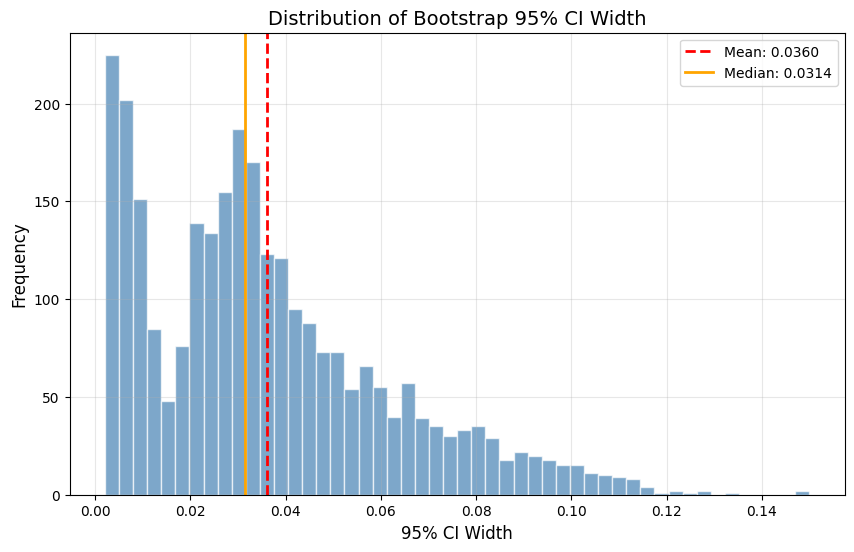

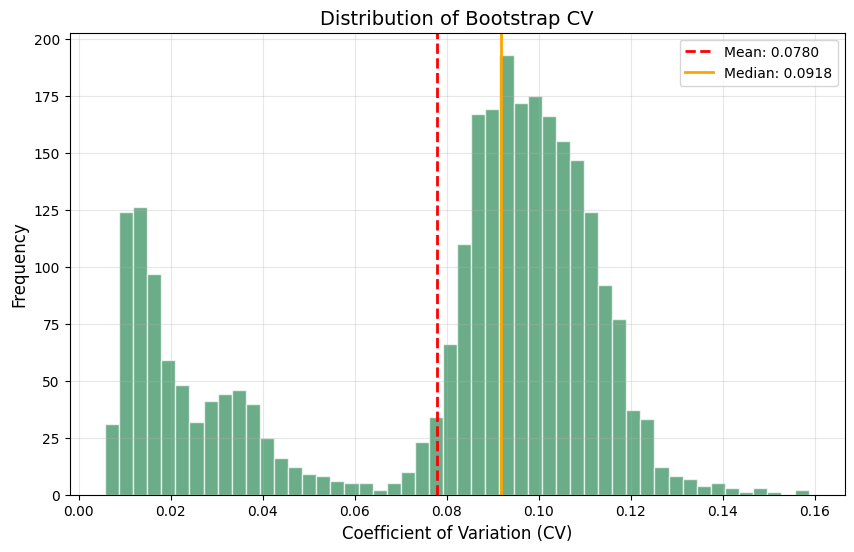

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Bootstrap CV'}, xlabel='Coefficient of Variation (CV)', ylabel='Frequency'>)

In [8]:
def plot_ci_width_hist(df: pd.DataFrame, save_path: str = None):
    """Fig 1: CI width distribution histogram."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(df['pV_ci_95_width'], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    
    mean_val = df['pV_ci_95_width'].mean()
    median_val = df['pV_ci_95_width'].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')
    
    ax.set_xlabel('95% CI Width', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Bootstrap 95% CI Width', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

def plot_cv_hist(df: pd.DataFrame, save_path: str = None):
    """Fig 2: CV distribution histogram."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(df['pV_cv'], bins=50, alpha=0.7, color='seagreen', edgecolor='white')
    
    mean_val = df['pV_cv'].mean()
    median_val = df['pV_cv'].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
    ax.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_val:.4f}')
    
    ax.set_xlabel('Coefficient of Variation (CV)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Bootstrap CV', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Plot Fig 1 & 2
plot_ci_width_hist(df, OUTPUT_DIR / 'fig_01_ci_width_hist.png')
plot_cv_hist(df, OUTPUT_DIR / 'fig_02_cv_hist.png')

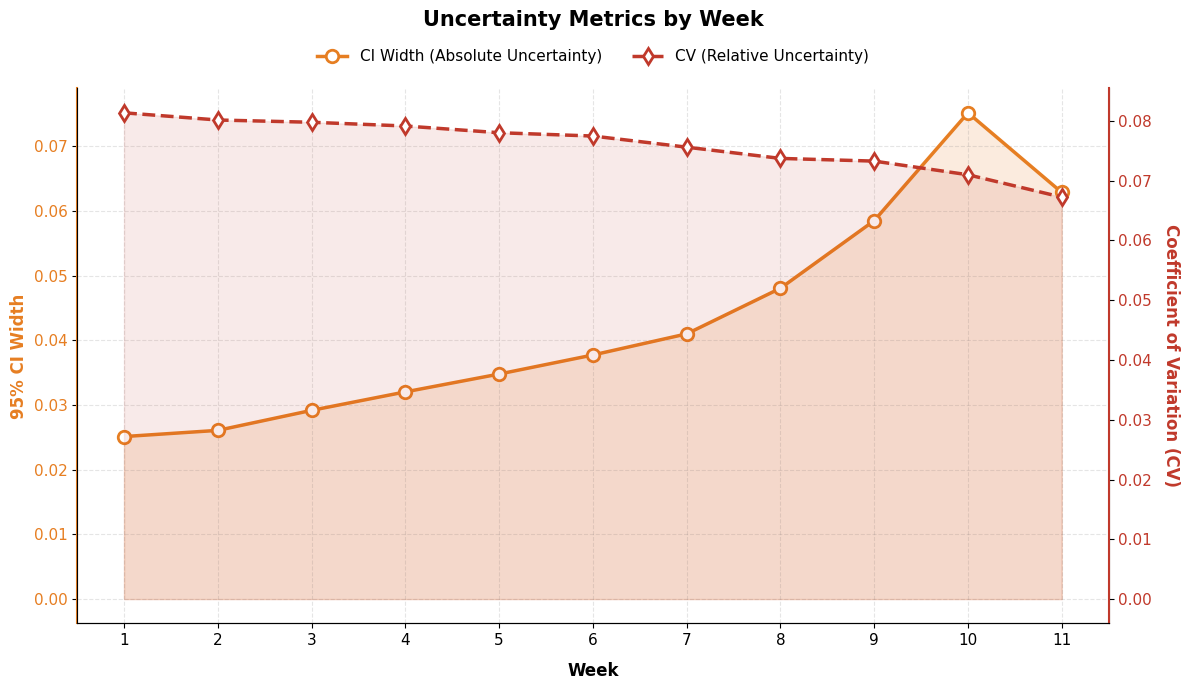

(<Figure size 1200x700 with 2 Axes>,
 (<Axes: title={'center': 'Uncertainty Metrics by Week'}, xlabel='Week', ylabel='95% CI Width'>,
  <Axes: ylabel='Coefficient of Variation (CV)'>))

In [9]:
def plot_uncertainty_by_week_combined(by_week_df: pd.DataFrame, save_path: str = None):
    """Fig 3-4: Combined plot of CI width and CV by week with improved aesthetics."""
    # Use a cleaner styling approach
    
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    weeks = by_week_df['week'].values
    
    # Colors - Professional Palette
    color_ci = '#E67E22'  # Pumpkin Orange
    color_cv = '#C0392B'  # Strong Red
    
    # === Axis 1: CI Width ===
    ci_means = by_week_df['ci_width_mean'].values
    
    # Line with white-filled markers for cleaner look
    l1, = ax1.plot(weeks, ci_means, 'o-', color=color_ci, linewidth=2.5, 
             markersize=9, markerfacecolor='white', markeredgewidth=2, 
             markeredgecolor=color_ci, label='CI Width (Absolute Uncertainty)', zorder=10)
    
    # Gradient fill
    ax1.fill_between(weeks, 0, ci_means, color=color_ci, alpha=0.15)
    
    ax1.set_xlabel('Week', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('95% CI Width', fontsize=12, color=color_ci, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_ci, labelsize=11)
    ax1.tick_params(axis='x', labelsize=11)
    
    # Grid customization
    ax1.grid(alpha=0.2, linestyle='--', color='gray')
    
    ax1.set_xlim(0.5, max(weeks) + 0.5)
    ax1.set_xticks(weeks)
    
    # === CV on secondary y-axis ===
    ax2 = ax1.twinx()
    cv_means = by_week_df['cv_mean'].values
    
    # Line with white-filled markers
    l2, = ax2.plot(weeks, cv_means, 'd--', color=color_cv, linewidth=2.5, 
             markersize=8, markerfacecolor='white', markeredgewidth=2,
             markeredgecolor=color_cv, label='CV (Relative Uncertainty)', zorder=10)
    
    # Gradient fill
    ax2.fill_between(weeks, 0, cv_means, color=color_cv, alpha=0.1)
    
    ax2.set_ylabel('Coefficient of Variation (CV)', fontsize=12, color=color_cv, fontweight='bold', rotation=270, labelpad=20)
    ax2.tick_params(axis='y', labelcolor=color_cv, labelsize=11)
    
    # Beautify spines
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    ax1.spines['left'].set_color(color_ci)
    ax1.spines['left'].set_linewidth(1.5)
    ax2.spines['right'].set_color(color_cv)
    ax2.spines['right'].set_linewidth(1.5)
    
    ax1.set_title('Uncertainty Metrics by Week', fontsize=15, fontweight='bold', pad=45)
    
    # Independent Legend placed ABOVE the plot to prevent overlap
    lines = [l1, l2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.02), 
               ncol=2, frameon=False, fontsize=11)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, (ax1, ax2)

# Plot combined Fig 3-4
plot_uncertainty_by_week_combined(by_week_df, OUTPUT_DIR / 'fig_03_04_uncertainty_by_week_combined.png')

/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/4136763037.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=rule_types, patch_artist=True)


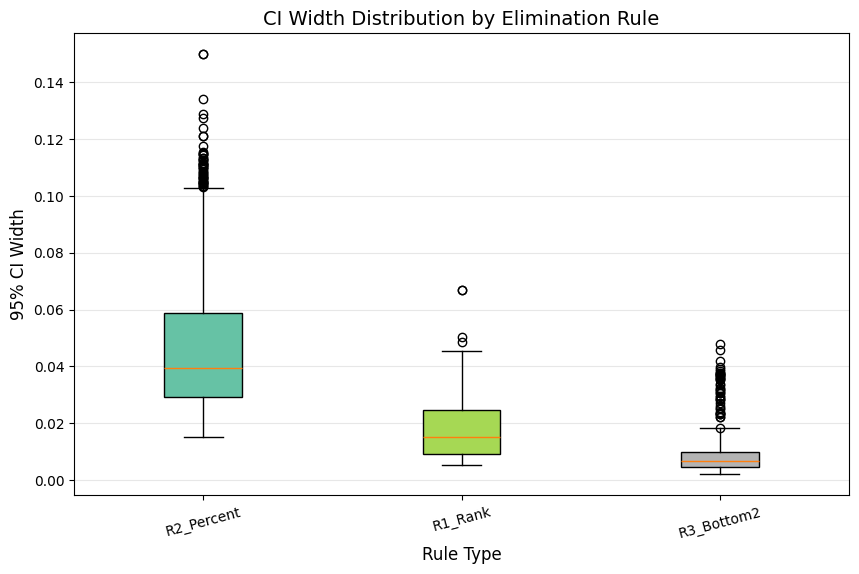

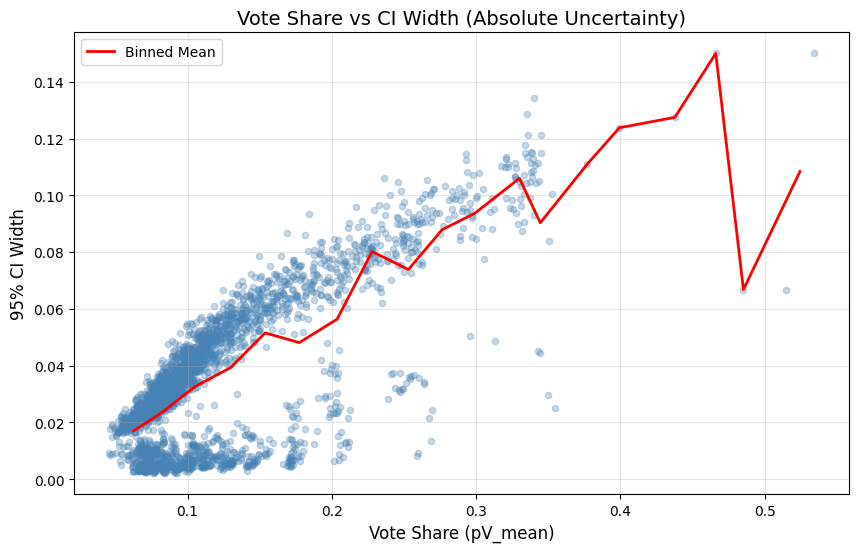

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Vote Share vs CI Width (Absolute Uncertainty)'}, xlabel='Vote Share (pV_mean)', ylabel='95% CI Width'>)

In [10]:
def plot_ci_width_by_rule_boxplot(df: pd.DataFrame, save_path: str = None):
    """Fig 5: Boxplot of CI width by rule_type."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rule_types = df['rule_type'].unique()
    data = [df[df['rule_type'] == r]['pV_ci_95_width'].values for r in rule_types]
    
    bp = ax.boxplot(data, labels=rule_types, patch_artist=True)
    colors = plt.cm.Set2(np.linspace(0, 1, len(rule_types)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_xlabel('Rule Type', fontsize=12)
    ax.set_ylabel('95% CI Width', fontsize=12)
    ax.set_title('CI Width Distribution by Elimination Rule', fontsize=14)
    ax.grid(alpha=0.3, axis='y')
    plt.xticks(rotation=15)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

def plot_pv_vs_ci_width(df: pd.DataFrame, save_path: str = None):
    """Fig 6: Scatter plot of pV_mean vs CI width."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(df['pV_mean'], df['pV_ci_95_width'], alpha=0.3, s=20, color='steelblue')
    
    # Add binned mean line
    df_temp = df.copy()
    df_temp['pV_bin'] = pd.cut(df_temp['pV_mean'], bins=20)
    binned = df_temp.groupby('pV_bin', observed=True).agg({
        'pV_mean': 'mean',
        'pV_ci_95_width': 'mean'
    }).dropna()
    ax.plot(binned['pV_mean'], binned['pV_ci_95_width'], 'r-', linewidth=2, label='Binned Mean')
    
    ax.set_xlabel('Vote Share (pV_mean)', fontsize=12)
    ax.set_ylabel('95% CI Width', fontsize=12)
    ax.set_title('Vote Share vs CI Width (Absolute Uncertainty)', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Plot Fig 5 & 6
plot_ci_width_by_rule_boxplot(df, OUTPUT_DIR / 'fig_05_ci_width_by_rule.png')
plot_pv_vs_ci_width(df, OUTPUT_DIR / 'fig_06_pv_vs_ci_width.png')

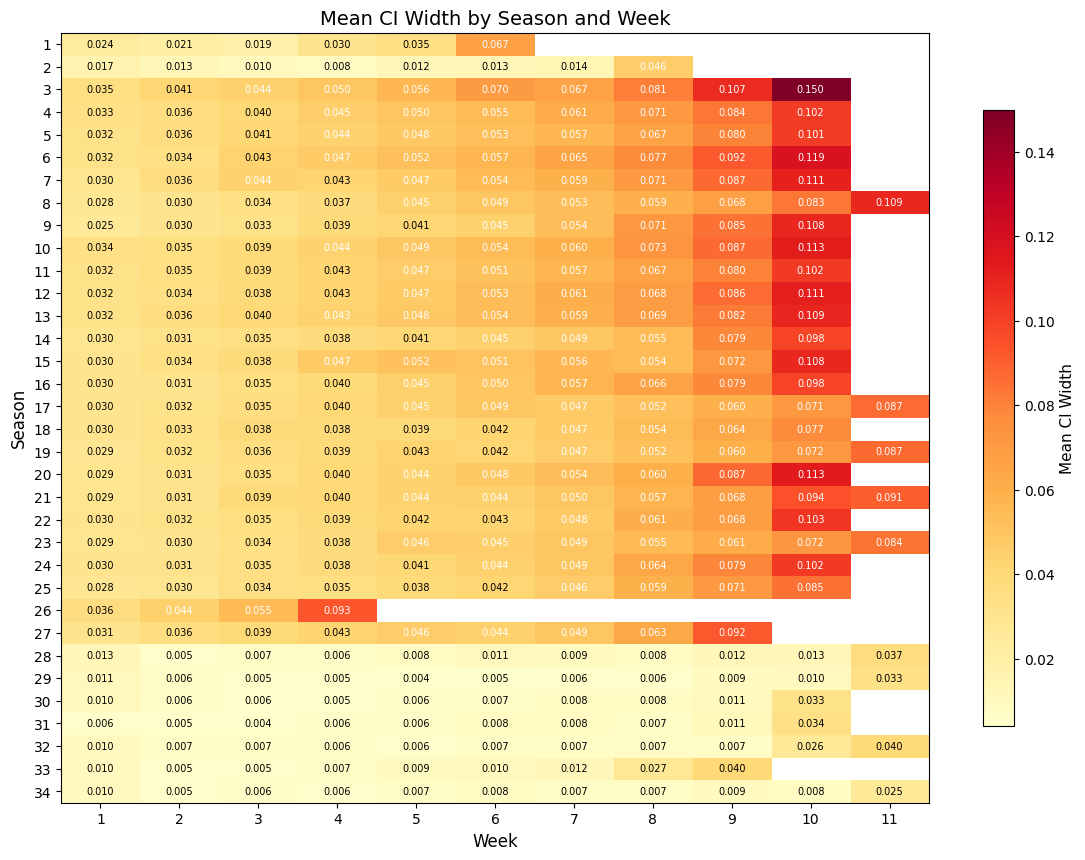

(<Figure size 1400x1000 with 2 Axes>,
 <Axes: title={'center': 'Mean CI Width by Season and Week'}, xlabel='Week', ylabel='Season'>)

In [11]:
def plot_heatmap_season_week(df: pd.DataFrame, save_path: str = None):
    """Fig 7: Heatmap of mean CI width by season x week."""
    pivot = df.groupby(['season', 'week'])['pV_ci_95_width'].mean().unstack()
    
    fig, ax = plt.subplots(figsize=(14, 10))
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    
    ax.set_xlabel('Week', fontsize=12)
    ax.set_ylabel('Season', fontsize=12)
    ax.set_title('Mean CI Width by Season and Week', fontsize=14)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Mean CI Width', fontsize=11)
    
    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                text_color = 'white' if val > pivot.values[~np.isnan(pivot.values)].mean() else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=text_color)
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# Plot Fig 7
plot_heatmap_season_week(df, OUTPUT_DIR / 'fig_07_heatmap_season_week.png')

## 5. Export Tables and Paper Snippet

In [12]:
# Rule comparison table
def create_rule_comparison(by_rule_df: pd.DataFrame) -> pd.DataFrame:
    """Create relative comparison between rules."""
    comp = by_rule_df[['rule_type', 'ci_width_mean', 'cv_mean', 'n_obs']].copy()
    baseline = comp[comp['rule_type'].str.contains('R1')]['ci_width_mean'].values
    if len(baseline) > 0:
        comp['ci_width_vs_R1'] = comp['ci_width_mean'] / baseline[0]
    else:
        comp['ci_width_vs_R1'] = np.nan
    return comp

# Certainty ranking by (season, week)
def create_certainty_ranking(df: pd.DataFrame) -> pd.DataFrame:
    """Compute CI width ranking percentile for each (season, week)."""
    ranking = df.groupby(['season', 'week']).agg({
        'pV_ci_95_width': 'mean',
        'pV_cv': 'mean',
        'celebrity_name': 'count'
    }).reset_index()
    ranking.columns = ['season', 'week', 'mean_ci_width', 'mean_cv', 'n_contestants']
    ranking['ci_width_rank_pct'] = ranking['mean_ci_width'].rank(pct=True)
    return ranking

rule_comparison_df = create_rule_comparison(by_rule_df)
certainty_ranking_df = create_certainty_ranking(df)

print("Rule comparison:")
display(rule_comparison_df)
print("\nCertainty ranking (top 10 most uncertain season-weeks):")
display(certainty_ranking_df.nlargest(10, 'mean_ci_width'))

Rule comparison:


,rule_type,ci_width_mean,cv_mean,n_obs,ci_width_vs_R1
0,R1_Rank,0.0188,0.0284,78,1.0000
1,R2_Percent,0.0462,0.0994,1997,2.4621
2,R3_Bottom2,0.0087,0.0225,702,0.4625



Certainty ranking (top 10 most uncertain season-weeks):


,season,week,mean_ci_width,mean_cv,n_contestants,ci_width_rank_pct
23,3,10,0.1500,0.0773,2,1.0000
53,6,10,0.1186,0.0942,3,0.9970
196,20,10,0.1129,0.0863,3,0.9940
94,10,10,0.1126,0.0870,3,0.9910
114,12,10,0.1112,0.0909,3,0.9881
63,7,10,0.1110,0.0866,3,0.9851
124,13,10,0.1091,0.0885,3,0.9821
74,8,11,0.1089,0.0879,3,0.9791
144,15,10,0.1085,0.0872,3,0.9761
84,9,10,0.1084,0.0854,3,0.9731


In [13]:
def export_tables_and_snippet(overall_stats, by_week_df, by_rule_df, by_contestant_df,
                               top10_uncertain, top10_certain, by_share_quartile_df,
                               by_elimination_df, season_bootstrap_df, rule_comparison_df,
                               certainty_ranking_df, output_dir):
    """Export all tables to Excel and CSV, and generate paper snippet."""
    
    # 1. Save overall summary as JSON
    with open(output_dir / 'overall_summary.json', 'w') as f:
        json.dump({k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
                   for k, v in overall_stats.items()}, f, indent=2)
    print("Saved: overall_summary.json")
    
    # 2. Save all tables to Excel (multiple sheets)
    with pd.ExcelWriter(output_dir / 'tables.xlsx', engine='openpyxl') as writer:
        pd.DataFrame([overall_stats]).T.to_excel(writer, sheet_name='overall')
        by_week_df.to_excel(writer, sheet_name='by_week', index=False)
        by_rule_df.to_excel(writer, sheet_name='by_rule', index=False)
        by_contestant_df.to_excel(writer, sheet_name='by_contestant', index=False)
        top10_uncertain.to_excel(writer, sheet_name='top10_uncertain', index=False)
        top10_certain.to_excel(writer, sheet_name='top10_certain', index=False)
        by_share_quartile_df.to_excel(writer, sheet_name='by_share_quartile', index=False)
        by_elimination_df.to_excel(writer, sheet_name='by_elimination', index=False)
        season_bootstrap_df.reset_index().to_excel(writer, sheet_name='season_bootstrap_B', index=False)
        rule_comparison_df.to_excel(writer, sheet_name='rule_comparison', index=False)
        certainty_ranking_df.to_excel(writer, sheet_name='certainty_ranking', index=False)
    print("Saved: tables.xlsx")
    
    # 3. Save individual CSVs
    csv_tables = {
        'overall': pd.DataFrame([overall_stats]).T,
        'by_week': by_week_df,
        'by_rule': by_rule_df,
        'by_contestant': by_contestant_df,
        'top10_uncertain': top10_uncertain,
        'top10_certain': top10_certain,
        'by_share_quartile': by_share_quartile_df,
        'by_elimination': by_elimination_df,
        'season_bootstrap_B': season_bootstrap_df.reset_index(),
        'rule_comparison': rule_comparison_df,
        'certainty_ranking': certainty_ranking_df
    }
    for name, tbl in csv_tables.items():
        tbl.to_csv(output_dir / f'{name}.csv', index=False)
    print(f"Saved: {len(csv_tables)} CSV files")
    
    return csv_tables

csv_tables = export_tables_and_snippet(
    overall_stats, by_week_df, by_rule_df, by_contestant_df,
    top10_uncertain, top10_certain, by_share_quartile_df,
    by_elimination_df, season_bootstrap_df, rule_comparison_df,
    certainty_ranking_df, OUTPUT_DIR
)

Saved: overall_summary.json
Saved: tables.xlsx
Saved: 11 CSV files


In [14]:
def generate_paper_snippet(overall_stats, by_week_df, by_rule_df, by_share_quartile_df, 
                           by_elimination_df, output_dir):
    """Generate paper-ready markdown snippet with auto-filled statistics."""
    
    s = overall_stats
    
    # Week trend analysis
    week_first = by_week_df.iloc[0]
    week_last = by_week_df.iloc[-1]
    ci_trend = "increases" if week_last['ci_width_mean'] > week_first['ci_width_mean'] else "decreases"
    cv_trend = "increases" if week_last['cv_mean'] > week_first['cv_mean'] else "decreases"
    
    snippet_en = f"""## Uncertainty Quantification (English)

### Bootstrap Resampling Methodology

To quantify uncertainty in our vote share estimates, we employed **season-level bootstrap resampling**. 
This approach preserves the within-season correlation structure by resampling entire seasons rather than 
individual observations. For each bootstrap iteration, we re-estimated vote shares and computed the 
resulting prediction. Across all observations, the number of bootstrap samples ranged from 
**B = {s['bootstrap_B_min']}** to **{s['bootstrap_B_max']}** (median: {s['bootstrap_B_median']:.0f}).

### Certainty Metrics

We evaluated prediction certainty using two complementary metrics:

1. **95% Confidence Interval Width (CI Width)**: The absolute uncertainty, computed as the difference 
   between the 97.5th and 2.5th percentiles of the bootstrap distribution.
2. **Coefficient of Variation (CV)**: The relative uncertainty, defined as the bootstrap standard 
   deviation divided by the bootstrap mean.

### Overall Certainty

Across **{s['n_obs']}** contestant-week observations spanning **{s['n_seasons']}** seasons, 
**{s['n_weeks']}** unique weeks, and **{s['n_contestants']}** contestants:

- **CI Width**: mean = {s['ci_width_mean']:.4f}, median = {s['ci_width_median']:.4f}, 
  IQR = [{s['ci_width_p25']:.4f}, {s['ci_width_p75']:.4f}], P10 = {s['ci_width_p10']:.4f}, P90 = {s['ci_width_p90']:.4f}
- **CV**: mean = {s['cv_mean']:.4f} ({s['cv_mean']*100:.2f}%), median = {s['cv_median']:.4f}, 
  IQR = [{s['cv_p25']:.4f}, {s['cv_p75']:.4f}], P10 = {s['cv_p10']:.4f}, P90 = {s['cv_p90']:.4f}

The P90/P10 ratio for CI width is **{s['ci_width_p90_p10_ratio']:.2f}**, and for CV is **{s['cv_p90_p10_ratio']:.2f}**, 
indicating substantial heterogeneity in certainty across observations.

### Heterogeneity Analysis

**By Week**: Mean CI width {ci_trend} from {week_first['ci_width_mean']:.4f} (Week {int(week_first['week'])}) 
to {week_last['ci_width_mean']:.4f} (Week {int(week_last['week'])}), while CV {cv_trend} from 
{week_first['cv_mean']:.4f} to {week_last['cv_mean']:.4f}. This divergence reflects that later weeks 
feature fewer remaining contestants with larger vote shares, leading to wider absolute intervals 
but potentially smaller relative uncertainty.

**By Vote Share Quartile**: Contestants in the highest vote share quartile (Q4) exhibit 
mean CI width of {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q4 (highest)']['ci_width_mean'].values[0]:.4f} 
vs. {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q1 (lowest)']['ci_width_mean'].values[0]:.4f} for Q1, 
while their CV is {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q4 (highest)']['cv_mean'].values[0]:.4f} 
vs. {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q1 (lowest)']['cv_mean'].values[0]:.4f}.

**By Elimination Status**: Eliminated contestants show mean CI width = 
{by_elimination_df[by_elimination_df['status']=='Eliminated']['ci_width_mean'].values[0]:.4f} 
vs. {by_elimination_df[by_elimination_df['status']=='Not Eliminated']['ci_width_mean'].values[0]:.4f} for non-eliminated.

---

"""

    snippet_cn = f"""## 不确定性量化（中文）

### Bootstrap 重抽样方法

为量化投票份额估计的不确定性，我们采用了**季级别 Bootstrap 重抽样**方法。该方法通过对整个赛季
进行重抽样（而非单个观测），保留了季内的相关结构。每次迭代重新估计投票份额并计算预测结果。
所有观测中，Bootstrap 样本数范围为 **B = {s['bootstrap_B_min']}** 至 **{s['bootstrap_B_max']}**
（中位数：{s['bootstrap_B_median']:.0f}）。

### 确定性度量

我们使用两个互补指标评估预测确定性：

1. **95% 置信区间宽度 (CI Width)**：绝对不确定性，计算为 Bootstrap 分布的 97.5 与 2.5 百分位数之差。
2. **变异系数 (CV)**：相对不确定性，定义为 Bootstrap 标准差除以 Bootstrap 均值。

### 总体确定性

在 **{s['n_obs']}** 个选手-周观测（跨越 **{s['n_seasons']}** 个赛季、**{s['n_weeks']}** 个周次、
**{s['n_contestants']}** 位选手）中：

- **CI Width**: 均值 = {s['ci_width_mean']:.4f}，中位数 = {s['ci_width_median']:.4f}，
  IQR = [{s['ci_width_p25']:.4f}, {s['ci_width_p75']:.4f}]，P10 = {s['ci_width_p10']:.4f}，P90 = {s['ci_width_p90']:.4f}
- **CV**: 均值 = {s['cv_mean']:.4f} ({s['cv_mean']*100:.2f}%)，中位数 = {s['cv_median']:.4f}，
  IQR = [{s['cv_p25']:.4f}, {s['cv_p75']:.4f}]，P10 = {s['cv_p10']:.4f}，P90 = {s['cv_p90']:.4f}

CI Width 的 P90/P10 比值为 **{s['ci_width_p90_p10_ratio']:.2f}**，CV 的比值为 **{s['cv_p90_p10_ratio']:.2f}**，
表明观测间确定性存在显著异质性。

### 异质性分析

**按周次**：平均 CI Width 从第 {int(week_first['week'])} 周的 {week_first['ci_width_mean']:.4f} 
{"上升" if ci_trend == "increases" else "下降"}至第 {int(week_last['week'])} 周的 {week_last['ci_width_mean']:.4f}；
而 CV 从 {week_first['cv_mean']:.4f} {"上升" if cv_trend == "increases" else "下降"}至 {week_last['cv_mean']:.4f}。
这种分化反映了后期剩余选手更少、份额更大，导致绝对区间变宽但相对不确定性可能降低。

**按份额分位**：最高份额组 (Q4) 的平均 CI Width 为 
{by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q4 (highest)']['ci_width_mean'].values[0]:.4f}，
而最低组 (Q1) 为 {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q1 (lowest)']['ci_width_mean'].values[0]:.4f}；
CV 分别为 {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q4 (highest)']['cv_mean'].values[0]:.4f} 
和 {by_share_quartile_df[by_share_quartile_df['share_quartile']=='Q1 (lowest)']['cv_mean'].values[0]:.4f}。

**按淘汰状态**：被淘汰选手的平均 CI Width = 
{by_elimination_df[by_elimination_df['status']=='Eliminated']['ci_width_mean'].values[0]:.4f}，
未淘汰选手为 {by_elimination_df[by_elimination_df['status']=='Not Eliminated']['ci_width_mean'].values[0]:.4f}。
"""

    full_snippet = snippet_en + snippet_cn
    
    with open(output_dir / 'paper_snippet.md', 'w', encoding='utf-8') as f:
        f.write(full_snippet)
    
    print("Saved: paper_snippet.md")
    return full_snippet

paper_snippet = generate_paper_snippet(
    overall_stats, by_week_df, by_rule_df, by_share_quartile_df, 
    by_elimination_df, OUTPUT_DIR
)

print("\n" + "="*60)
print("PAPER SNIPPET PREVIEW")
print("="*60)
print(paper_snippet[:2000] + "\n...")

Saved: paper_snippet.md

PAPER SNIPPET PREVIEW
## Uncertainty Quantification (English)

### Bootstrap Resampling Methodology

To quantify uncertainty in our vote share estimates, we employed **season-level bootstrap resampling**. 
This approach preserves the within-season correlation structure by resampling entire seasons rather than 
individual observations. For each bootstrap iteration, we re-estimated vote shares and computed the 
resulting prediction. Across all observations, the number of bootstrap samples ranged from 
**B = 86** to **114** (median: 100).

### Certainty Metrics

We evaluated prediction certainty using two complementary metrics:

1. **95% Confidence Interval Width (CI Width)**: The absolute uncertainty, computed as the difference 
   between the 97.5th and 2.5th percentiles of the bootstrap distribution.
2. **Coefficient of Variation (CV)**: The relative uncertainty, defined as the bootstrap standard 
   deviation divided by the bootstrap mean.

### Overall Certain

## 6. Summary and Output Verification

In [15]:
# Verify all outputs exist
import os

expected_outputs = [
    'overall_summary.json',
    'tables.xlsx',
    'overall.csv', 'by_week.csv', 'by_rule.csv', 'by_contestant.csv',
    'top10_uncertain.csv', 'top10_certain.csv', 'by_share_quartile.csv',
    'by_elimination.csv', 'season_bootstrap_B.csv', 'rule_comparison.csv',
    'certainty_ranking.csv', 'paper_snippet.md',
    'fig_01_ci_width_hist.png', 'fig_02_cv_hist.png',
    'fig_03_ci_width_by_week.png', 'fig_04_cv_by_week.png',
    'fig_05_ci_width_by_rule.png', 'fig_06_pv_vs_ci_width.png',
    'fig_07_heatmap_season_week.png'
]

print("="*60)
print("OUTPUT VERIFICATION")
print("="*60)

missing = []
for f in expected_outputs:
    path = OUTPUT_DIR / f
    if path.exists():
        size = path.stat().st_size
        print(f"✓ {f} ({size:,} bytes)")
    else:
        print(f"✗ {f} - MISSING")
        missing.append(f)

if missing:
    print(f"\nWARNING: {len(missing)} files missing!")
else:
    print(f"\n✓ All {len(expected_outputs)} output files created successfully!")

print(f"\nOutput directory: {OUTPUT_DIR.absolute()}")

OUTPUT VERIFICATION
✓ overall_summary.json (867 bytes)
✓ tables.xlsx (73,161 bytes)
✓ overall.csv (409 bytes)
✓ by_week.csv (2,832 bytes)
✓ by_rule.csv (770 bytes)
✓ by_contestant.csv (56,546 bytes)
✓ top10_uncertain.csv (645 bytes)
✓ top10_certain.csv (639 bytes)
✓ by_share_quartile.csv (525 bytes)
✓ by_elimination.csv (356 bytes)
✓ season_bootstrap_B.csv (939 bytes)
✓ rule_comparison.csv (261 bytes)
✓ certainty_ranking.csv (22,352 bytes)
✓ paper_snippet.md (3,787 bytes)
✓ fig_01_ci_width_hist.png (91,325 bytes)
✓ fig_02_cv_hist.png (99,919 bytes)
✓ fig_03_ci_width_by_week.png (187,399 bytes)
✓ fig_04_cv_by_week.png (184,504 bytes)
✓ fig_05_ci_width_by_rule.png (124,325 bytes)
✓ fig_06_pv_vs_ci_width.png (545,650 bytes)
✓ fig_07_heatmap_season_week.png (729,520 bytes)

✓ All 21 output files created successfully!

Output directory: /Users/luoyiti/Project/MCM_2026/outputs


print("="*60)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*60)
print(f"Total observations analyzed: {len(df)}")
print(f"Seasons: {df['season'].nunique()}, Weeks: {df['week'].nunique()}, Contestants: {df['celebrity_name'].nunique()}")
print(f"\nAll outputs saved to: {OUTPUT_DIR.absolute()}")

Using data loaded in memory (df).

EXTENT OF UNCERTAINTY COMPARISON (Ranked by Mean CI Width)


<>:250: SyntaxWarning: invalid escape sequence '\p'
<>:250: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/251953382.py:250: SyntaxWarning: invalid escape sequence '\p'
  ax.text(1.02, -0.05, 'Bubble Size $\propto$ Vote Share (pV)', transform=ax.transAxes, fontsize=10, ha='left')


,celebrity_name,group,mean_W,mean_CV,n_points,dominant_rule_type
249,Mario Lopez,MostUncertain,0.0860,0.0909,10,R2_Percent
168,Jason Taylor,MostUncertain,0.0825,0.1083,10,R2_Percent
49,Brooke Burke,MostUncertain,0.0786,0.1008,10,R2_Percent
120,Evan Lysacek,MostUncertain,0.0783,0.1028,10,R2_Percent
222,Kristi Yamaguchi,MostUncertain,0.0774,0.1087,10,R2_Percent
381,Trevor Donovan,LeastUncertain,0.0061,0.0156,9,R3_Bottom2
193,Johnny Weir,LeastUncertain,0.0058,0.0160,10,R3_Bottom2
141,Heidi D'Amelio,LeastUncertain,0.0057,0.0160,8,R3_Bottom2
347,Selma Blair,LeastUncertain,0.0045,0.0154,5,R3_Bottom2
169,Jeannie Mai,LeastUncertain,0.0042,0.0148,7,R3_Bottom2


Summary table saved to: outputs/top5_bottom5_uncertainty_summary.csv


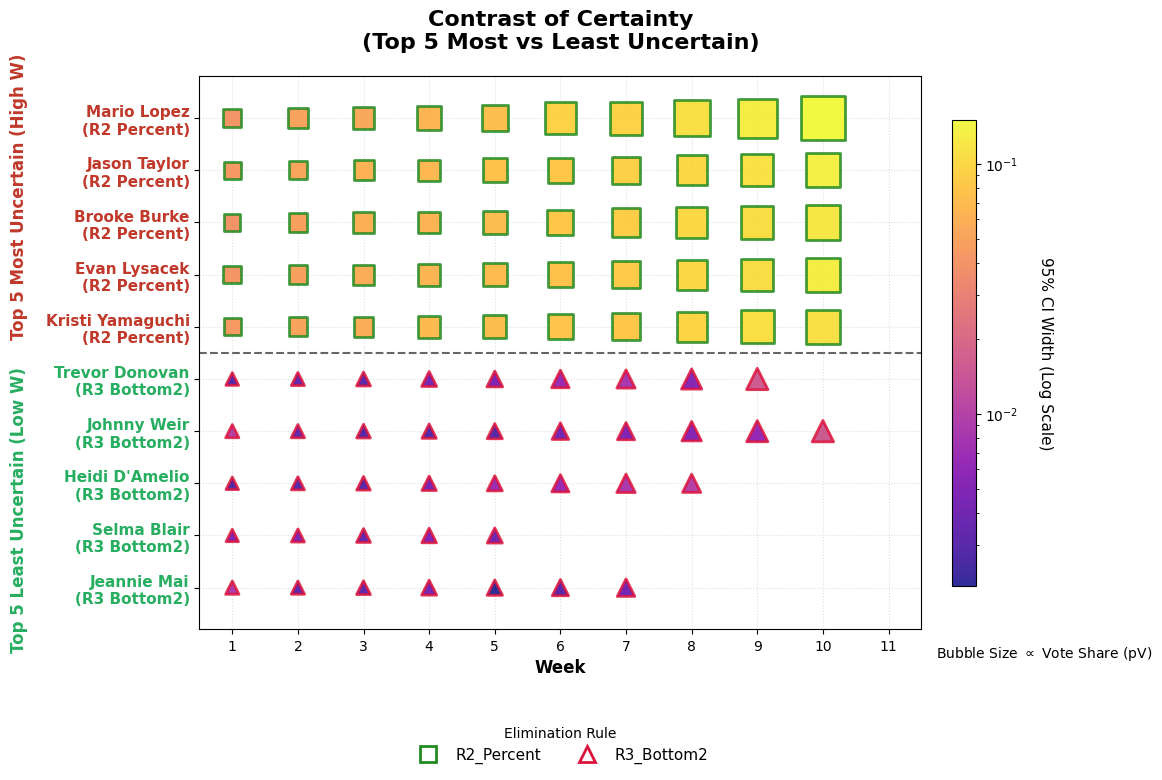

Bubble heatmap saved to: outputs/fig_bubble_uncertainty_topbottom5.png


In [16]:
"""
=============================================================================
Supplementary Analysis: Contrast of Certainty (Top 5 vs Bottom 5)
=============================================================================
Identifies the Top 5 High-Uncertainty and Top 5 Low-Uncertainty contestants,
and visualizes their weekly uncertainty evolution using a bubble heatmap.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from pathlib import Path

# Ensure output directory exists (using global OUTPUT_DIR if defined, else default)
if 'OUTPUT_DIR' not in locals():
    OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def prepare_topbottom5(df_in: pd.DataFrame):
    """
    Selects Top 5 Most Uncertain and Top 5 Least Uncertain contestants.
    Aggregates metrics by (celebrity, week) for plotting.
    """
    # 1. Check required columns
    req_cols = ['celebrity_name', 'week', 'rule_type', 'pV_mean', 'pV_ci_95_width']
    missing = [c for c in req_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # 2. Filter weeks (Standard season usually 1-11)
    df_clean = df_in[(df_in['week'] >= 1) & (df_in['week'] <= 11)].copy()
    
    # 3. Aggregate to contestant level to find Top/Bottom 10
    # Group by celebrity_name to get global uncertainty ranking
    # Handle missing pV_cv if not present
    agg_dict = {
        'pV_ci_95_width': 'mean',
        'rule_type': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0],
        'week': 'count' # Count points
    }
    if 'pV_cv' in df_clean.columns:
        agg_dict['pV_cv'] = 'mean'
        
    contestant_stats = df_clean.groupby('celebrity_name').agg(agg_dict).reset_index()
    
    # Rename for clarity
    contestant_stats.rename(columns={
        'pV_ci_95_width': 'mean_W', 
        'pV_cv': 'mean_CV',
        'week': 'n_points',
        'rule_type': 'dominant_rule_type'
    }, inplace=True)
    
    # Sort by mean_W
    contestant_stats = contestant_stats.sort_values('mean_W', ascending=False)
    
    n = len(contestant_stats)
    if n <= 10:
        # If fewer than 10 total, just take all
        df_rank = contestant_stats.copy()
        df_rank['group'] = 'All'
    else:
        # Top 5 Most Uncertain (Largest W)
        top5 = contestant_stats.head(5).copy()
        top5['group'] = 'MostUncertain'
        
        # Bottom 5 Least Uncertain (Smallest W)
        bottom5 = contestant_stats.tail(5).copy()
        bottom5['group'] = 'LeastUncertain'
        
        # Combine
        df_rank = pd.concat([top5, bottom5])
    
    # Get the names of selected contestants
    selected_names = df_rank['celebrity_name'].values
    
    # 4. Filter original data for these contestants and aggregate (season handling)
    df_filtered = df_clean[df_clean['celebrity_name'].isin(selected_names)].copy()
    
    # Aggregation rule: (name, week) -> single point
    # W -> mean, pV -> mean, rule -> mode
    df_plot = df_filtered.groupby(['celebrity_name', 'week']).agg({
        'pV_ci_95_width': 'mean',
        'pV_mean': 'mean',
        'rule_type': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
    }).reset_index()
    
    return df_plot, df_rank

def plot_bubble_heatmap(df_plot, df_rank, outpath):
    """
    Plots the bubble heatmap with:
    - Y-Axis: Contestants sorted by Mean W
    - X-Axis: Week
    - Color: W (Plasma Colormap: Purple -> Red -> Yellow)
    - Size: pV_mean
    - Marker/Edge: Rule Type
    """
    # Define Y-axis order: 
    # We want "Most Uncertain" (High W, Top 5) at the TOP of the plot.
    # In Matplotlib scatter, y=0 is bottom.
    # So we sort df_rank ascending by mean_W (Smallest first -> Bottom).
    df_rank_sorted = df_rank.sort_values('mean_W', ascending=True).reset_index(drop=True)
    df_rank_sorted['y_pos'] = df_rank_sorted.index
    
    # Map y_pos back to df_plot
    name_to_y = pd.Series(df_rank_sorted.y_pos.values, index=df_rank_sorted.celebrity_name).to_dict()
    df_plot['y_pos'] = df_plot['celebrity_name'].map(name_to_y)
    
    # Setup Figure - smaller figure height since fewer rows
    fig, ax = plt.subplots(figsize=(12, 8)) 
    
    # -------------------------------------------------------------------------
    # SCALE SIZE by pV_mean
    # -------------------------------------------------------------------------
    p_min, p_max = df_plot['pV_mean'].min(), df_plot['pV_mean'].max()
    if p_max - p_min > 1e-6:
        df_plot['size_scaled'] = (df_plot['pV_mean'] - p_min) / (p_max - p_min)
    else:
        df_plot['size_scaled'] = 0.5
    
    # Bubble size formula: base + scale * factor
    # Min size 80, Max size ~900 (slightly larger bubbles since fewer rows)
    sizes = 80 + 900 * df_plot['size_scaled']
    
    # -------------------------------------------------------------------------
    # STYLING RULES
    # -------------------------------------------------------------------------
    # Markers mapping
    marker_map = {'R1_Rank': 'o', 'R2_Percent': 's', 'R3_Bottom2': '^'}
    # Edge colors mapping (distinct colors)
    edge_map =   {'R1_Rank': 'navy', 'R2_Percent': 'forestgreen', 'R3_Bottom2': 'crimson'}
    
    # Fallback for data rules not in dict
    unique_rules = df_plot['rule_type'].unique()
    
    # -------------------------------------------------------------------------
    # COLOR MAPPING (Uncertainty W) - "Purple -> Red -> Yellow"
    # -------------------------------------------------------------------------
    # Use 'plasma' colormap which fits this description perfectly (Purple-Red-Orange-Yellow)
    cmap = plt.cm.plasma
    # Use LogNorm for better contrast if W ranges widely
    norm = mcolors.LogNorm(vmin=df_plot['pV_ci_95_width'].min() + 1e-6, 
                           vmax=df_plot['pV_ci_95_width'].max())
    
    # -------------------------------------------------------------------------
    # PLOTTING
    # -------------------------------------------------------------------------
    # Loop per rule type to handle marker shapes
    plotted_rules = []
    
    for r_type in unique_rules:
        subset = df_plot[df_plot['rule_type'] == r_type]
        if subset.empty: continue
        
        m = marker_map.get(r_type, 'o')
        e = edge_map.get(r_type, '#333333')
        
        sc = ax.scatter(
            subset['week'], 
            subset['y_pos'], 
            s=sizes[subset.index], 
            c=subset['pV_ci_95_width'], 
            cmap=cmap, 
            norm=norm,
            marker=m,
            edgecolors=e,
            linewidth=2,
            alpha=0.85,
            label=r_type,
            zorder=3
        )
        plotted_rules.append(r_type)
        
    # -------------------------------------------------------------------------
    # AESTHETICS
    # -------------------------------------------------------------------------
    # Colorbar
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('95% CI Width (Log Scale)', rotation=270, labelpad=25, fontsize=11)
    
    # Y-Axis Labels (Contestants) with Rule Info
    # Format: "Name\n(Rule)"
    lbls = []
    for name in df_rank_sorted['celebrity_name']:
        rule = df_rank_sorted.loc[df_rank_sorted.celebrity_name == name, 'dominant_rule_type'].values[0]
        # Shorten rule name for display if needed
        rule_short = rule.replace('_', ' ') if isinstance(rule, str) else str(rule)
        lbls.append(f"{name}\n({rule_short})")

    ax.set_yticks(df_rank_sorted['y_pos'])
    ax.set_yticklabels(lbls, fontsize=11)
    
    # Color Y-labels by group
    for y, idx in zip(df_rank_sorted['y_pos'], df_rank_sorted.index):
        grp = df_rank_sorted.loc[idx, 'group']
        # Most Uncertain (High W) -> Top of plot -> Red/Purple theme (plasma end)
        # Least Uncertain (Low W) -> Bottom of plot -> Blue/Purple theme (plasma start)
        if grp == 'MostUncertain':
            ax.get_yticklabels()[int(y)].set_color('#C0392B') # Dark Red
            ax.get_yticklabels()[int(y)].set_fontweight('bold')
        elif grp == 'LeastUncertain':
            ax.get_yticklabels()[int(y)].set_color('#27AE60') # Green
            ax.get_yticklabels()[int(y)].set_fontweight('bold')

    ax.set_xticks(range(1, 12))
    ax.set_xlabel('Week', fontsize=12, fontweight='bold')
    ax.set_title("Contrast of Certainty\n(Top 5 Most vs Least Uncertain)", fontsize=16, fontweight='bold', pad=20)
    
    # Separator Line between Top 5 and Bottom 5 (Vertical Annotation Version)
    if 'group' in df_rank_sorted.columns and len(df_rank_sorted[df_rank_sorted.group=='MostUncertain']) == 5:
        split_y = 4.5
        ax.axhline(y=split_y, color='black', linestyle='--', linewidth=1.5, alpha=0.6, zorder=1)
        
        # Vertical Annotations on the Left (next to names)
        # Using blended transform: x in axes fraction (negative to be left of spine), y in data coords
        trans = ax.get_yaxis_transform()
        
        # Top 5 (Indices 5-9) -> Center y=7
        ax.text(-0.25, 7.5, 'Top 5 Most Uncertain (High W)', fontsize=12, 
                color='#C0392B', fontweight='bold', rotation='vertical', 
                va='center', ha='center', transform=trans)

        # Bottom 5 (Indices 0-4) -> Center y=2
        ax.text(-0.25, 1.5, 'Top 5 Least Uncertain (Low W)', fontsize=12, 
                color='#27AE60', fontweight='bold', rotation='vertical', 
                va='center', ha='center', transform=trans)

    ax.set_xlim(0.5, 11.5)
    # Give a bit more padding on Y for the fewer items
    ax.set_ylim(-0.8, len(df_rank_sorted) - 0.2)
    ax.grid(True, linestyle=':', alpha=0.4, zorder=0)
    
    # Custom Legend - Moved further down to prevent overlap
    handles_list = []
    # 1. Rules
    for r_type in sorted(plotted_rules):
        m = marker_map.get(r_type, 'o')
        e = edge_map.get(r_type, 'black')
        h = mlines.Line2D([], [], color='white', marker=m, markeredgecolor=e, 
                          label=r_type, markersize=12, markeredgewidth=2)
        handles_list.append(h)
        
    ax.legend(handles=handles_list, title='Elimination Rule', 
              loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False, fontsize=11)

    # Size Annotation
    ax.text(1.02, -0.05, 'Bubble Size $\propto$ Vote Share (pV)', transform=ax.transAxes, fontsize=10, ha='left')

    plt.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=600, bbox_inches='tight')
    plt.show()
    return fig, ax

# =============================================================================
# EXECUTION BLOCK
# =============================================================================

# Robust data loading: Use 'df' if available, otherwise filter warning/load
try:
    if 'df' in locals() and isinstance(df, pd.DataFrame):
        print("Using data loaded in memory (df).")
        df_source = df.copy()
    else:
        print("Loading data from CSV...")
        df_source = pd.read_csv('data/q1_bootstrap_uncertainty.csv')

    # 1. Prepare
    df_plot_final, df_rank_final = prepare_topbottom5(df_source)

    # 2. Display Table
    print("\n" + "="*60)
    print("EXTENT OF UNCERTAINTY COMPARISON (Ranked by Mean CI Width)")
    print("="*60)
    cols_show = ['celebrity_name', 'group', 'mean_W', 'mean_CV', 'n_points', 'dominant_rule_type']
    # Fallback if CV not calc
    cols_show = [c for c in cols_show if c in df_rank_final.columns]
    
    # Sort descending for display (Top 1 Uncertain first)
    display(df_rank_final.sort_values('mean_W', ascending=False)[cols_show].head(20))
    
    # Save CSV
    summary_csv = OUTPUT_DIR / 'top5_bottom5_uncertainty_summary.csv'
    df_rank_final.sort_values('mean_W', ascending=False).to_csv(summary_csv, index=False)
    print(f"Summary table saved to: {summary_csv}")

    # 3. Plot
    plot_tgt = OUTPUT_DIR / 'fig_bubble_uncertainty_topbottom5.png'
    fig_bubble, ax_bubble = plot_bubble_heatmap(df_plot_final, df_rank_final, plot_tgt)
    print(f"Bubble heatmap saved to: {plot_tgt}")

except Exception as ex:
    print(f"\nERROR in Bubble Heatmap Generation: {ex}")
    import traceback
    traceback.print_exc()

Generating Uncertainty Leaderboard...

UNCERTAINTY LEADERBOARD SUMMARY TABLE


,celebrity_name,group,mean_W,p25_W,p75_W,n_weeks,dominant_rule,mean_CV
19,Mario Lopez,MostUncertain,0.0860,0.0570,0.1071,10,R2_Percent,0.0909
18,Jason Taylor,MostUncertain,0.0825,0.0638,0.0979,10,R2_Percent,0.1083
17,Brooke Burke,MostUncertain,0.0786,0.0614,0.0987,10,R2_Percent,0.1008
16,Evan Lysacek,MostUncertain,0.0783,0.0595,0.0966,10,R2_Percent,0.1028
15,Kristi Yamaguchi,MostUncertain,0.0774,0.0611,0.0926,10,R2_Percent,0.1087
14,Shawn Johnson,MostUncertain,0.0756,0.0566,0.0919,11,R2_Percent,0.1074
13,Riker Lynch,MostUncertain,0.0752,0.0554,0.0908,10,R2_Percent,0.1020
12,Erin Andrews,MostUncertain,0.0746,0.0573,0.0900,10,R2_Percent,0.0953
11,Cristian de la Fuente,MostUncertain,0.0743,0.0582,0.0930,10,R2_Percent,0.1093
10,Rob Kardashian,MostUncertain,0.0736,0.0566,0.0886,10,R2_Percent,0.1029


Summary table saved to: outputs/leaderboard_top10_bottom10_summary.csv


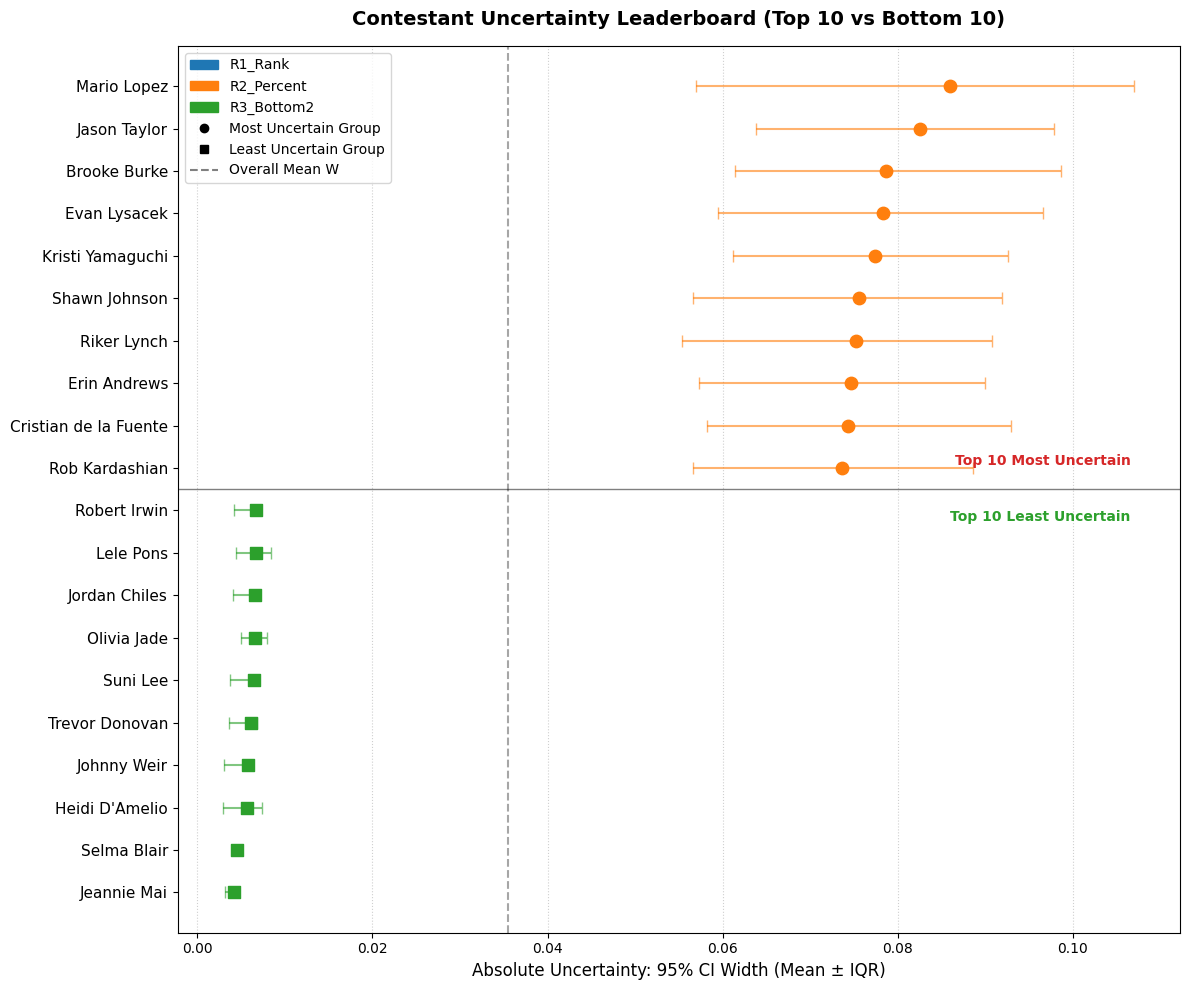

Leaderboard plot saved to: outputs/fig_leaderboard_top10_bottom10_W.png


In [17]:
"""
=============================================================================
Supplementary Analysis: Contestant Uncertainty Leaderboard
=============================================================================
Visualizes Top 10 High-Uncertainty and Top 10 Low-Uncertainty contestants
with error bars representing the spread of uncertainty across weeks.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from pathlib import Path

# Ensure output directory exists (using global OUTPUT_DIR if defined, else default)
if 'OUTPUT_DIR' not in locals():
    OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_uncertainty_data(path):
    """Load data and check required columns."""
    df = pd.read_csv(path)
    req_cols = ['celebrity_name', 'week', 'rule_type', 'pV_ci_95_width']
    missing = [c for c in req_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # Filter valid weeks
    df = df[(df['week'] >= 1) & (df['week'] <= 11)].copy()
    return df

def aggregate_week_level(df):
    """
    Aggregate to (celebrity_name, week) level.
    Handles multiple seasons/entires per week (e.g., if re-occurring).
    """
    agg_rules = {
        'pV_ci_95_width': 'mean',
        # Mode for rule_type (if tie, select first sorted)
        'rule_type': lambda x: sorted(x.mode())[0] if not x.mode().empty else x.iloc[0]
    }
    
    if 'pV_cv' in df.columns:
        agg_rules['pV_cv'] = 'mean'
        
    # Group by name and week
    df_week = df.groupby(['celebrity_name', 'week']).agg(agg_rules).reset_index()
    return df_week

def build_contestant_summary(df_week):
    """
    Compute contestant-level uncertainty metrics distribution across weeks.
    """
    # Define aggregation functions
    def q25(x): return x.quantile(0.25)
    def q75(x): return x.quantile(0.75)
    
    metrics = {
        'pV_ci_95_width': ['mean', 'median', q25, q75],
        'rule_type': lambda x: sorted(x.mode())[0] if not x.mode().empty else x.iloc[0],
        'week': 'count'
    }
    
    if 'pV_cv' in df_week.columns:
        metrics['pV_cv'] = ['mean', 'median', q25, q75]
        
    df_cont = df_week.groupby('celebrity_name').agg(metrics)
    
    # Flatten MultiIndex columns
    # e.g., (pV_ci_95_width, mean) -> mean_W
    flat_cols = []
    for col, stat in df_cont.columns:
        if col == 'pV_ci_95_width':
            if stat == '<lambda>': stat = 'mode' # Should not happen based on metrics dict
            suffix = '_W'
        elif col == 'pV_cv':
            suffix = '_CV'
        elif col == 'week':
            col = 'n_weeks'
            stat = ''
            suffix = ''
        elif col == 'rule_type':
            col = 'dominant_rule'
            stat = ''
            suffix = ''
        else:
            suffix = ''
            
        # Map stat names
        if stat == 'q25': stat = 'p25'
        if stat == 'q75': stat = 'p75'
        
        # Build new name
        if col in ['n_weeks', 'dominant_rule']:
            new_name = col
        else:
            new_name = f"{stat}{suffix}"
            
        flat_cols.append(new_name)
        
    df_cont.columns = flat_cols
    return df_cont.reset_index()

def select_top_bottom(df_cont, k=10):
    """Select Top K Most Uncertain and Bottom K Least Uncertain."""
    df_sorted = df_cont.sort_values('mean_W', ascending=False) # Descending for Most Uncertain
    
    n = len(df_sorted)
    if n <= 2 * k:
        df_sel = df_sorted.copy()
        # Assign groups
        df_sel['group'] = 'All' # Or split by median
        # Simple heuristic split if needed
        return df_sel
    
    top_k = df_sorted.head(k).copy()
    top_k['group'] = 'MostUncertain'
    
    bottom_k = df_sorted.tail(k).copy()
    bottom_k['group'] = 'LeastUncertain'
    # Sort Bottom K ascending for plotting (smallest at bottom visual)
    bottom_k = bottom_k.sort_values('mean_W', ascending=True)
    
    # Combine: Top K first (will be at top of y-axis), then Bottom K
    # We want plot ordering: Top 1 (Most Uncertain) at Y=Top, ..., Top 10, ... Bottom 10 (Most Certain)
    # So dataframe order should be: Top 1 ... Top 10 ... Bottom 10 ... Bottom 1
    # Actually, for plotting, y=0 is usually bottom. So we want Bottom 1 (Least) at y=0.
    # So we want DataFrame order: Bottom 1 -> ... -> Bottom 10 -> Top 10 -> ... -> Top 1 (Most Uncertain)
    
    # Correct Sort Order for Plotting (Y-axis ascending index)
    # Bottom (Smallest mean_W) -> Top (Largest mean_W)
    df_sel = pd.concat([bottom_k, top_k[::-1]]) # Reverse Top K to have largest at end
    
    # Reset index for plotting convenience
    return df_sel.reset_index(drop=True)

def plot_leaderboard(df_sel, overall_mean_W=None, outpath=None):
    """Plot horizontal error bar chart."""
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Data preparation
    y_pos = np.arange(len(df_sel))
    names = df_sel['celebrity_name']
    means = df_sel['mean_W']
    
    # Error bars (xerr expects relative values [left, right])
    # Left error = mean - p25, Right error = p75 - mean
    xerr_left = (means - df_sel['p25_W']).clip(lower=0)
    xerr_right = (df_sel['p75_W'] - means).clip(lower=0)
    xerr = [xerr_left, xerr_right]
    
    # Color mapping for Rules
    rule_colors = {'R1_Rank': '#1f77b4', 'R2_Percent': '#ff7f0e', 'R3_Bottom2': '#2ca02c'}
    colors = df_sel['dominant_rule'].map(rule_colors).fillna('gray')
    
    # Marker mapping for Groups
    # MostUncertain (Top) = 'o', LeastUncertain (Bottom) = 's'
    # Based on our sort logic: 
    # High indices -> Top group (Most Uncertain) -> 'o'
    # Low indices -> Bottom group (Least Uncertain) -> 's'
    # Let's map explicitly based on 'group' column if available
    markers = []
    for g in df_sel['group']:
        if g == 'MostUncertain': markers.append('o')
        elif g == 'LeastUncertain': markers.append('s')
        else: markers.append('D')
        
    # Plot Points and Error Bars
    for i, (y, m, c) in enumerate(zip(y_pos, means, colors)):
        ax.errorbar(m, y, xerr=[[xerr[0][i]], [xerr[1][i]]], 
                    fmt='none', ecolor=c, alpha=0.6, capsize=4, elinewidth=1.5)
        # Plot marker manually to control shape
        marker_shape = markers[i] if i < len(markers) else 'o'
        ax.scatter(m, y, marker=marker_shape, color=c, s=80, zorder=5)

    # Plot Overall Mean Line
    if overall_mean_W is not None:
        ax.axvline(overall_mean_W, color='gray', linestyle='--', alpha=0.7, label='Overall Mean W')
        
    # Split Line between Groups (if 20 items, split at 9.5)
    # Lower 10 items (indices 0-9) are Bottom 10
    # Upper 10 items (indices 10-19) are Top 10
    if len(df_sel) == 20:
        ax.axhline(9.5, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax.text(ax.get_xlim()[1]*0.95, 10, 'Top 10 Most Uncertain', va='bottom', ha='right', fontsize=10, fontweight='bold', color='#d62728')
        ax.text(ax.get_xlim()[1]*0.95, 9, 'Top 10 Least Uncertain', va='top', ha='right', fontsize=10, fontweight='bold', color='#2ca02c')

    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names, fontsize=11)
    ax.set_xlabel('Absolute Uncertainty: 95% CI Width (Mean ± IQR)', fontsize=12)
    ax.set_title('Contestant Uncertainty Leaderboard (Top 10 vs Bottom 10)', fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', linestyle=':', alpha=0.6)
    
    # Custom Legend
    # Rule Colors
    handles = [mpatches.Patch(color=c, label=l) for l, c in rule_colors.items()]
    # Group Shapes
    handles.append(mlines.Line2D([], [], color='k', marker='o', linestyle='None', label='Most Uncertain Group'))
    handles.append(mlines.Line2D([], [], color='k', marker='s', linestyle='None', label='Least Uncertain Group'))
    if overall_mean_W:
        handles.append(mlines.Line2D([], [], color='gray', linestyle='--', label='Overall Mean W'))
        
    ax.legend(handles=handles, loc='best', fontsize=10, frameon=True)
    
    plt.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# =============================================================================
# Execution
# =============================================================================
try:
    print("Generating Uncertainty Leaderboard...")
    
    # 1. Load
    df_raw = load_uncertainty_data('data/q1_bootstrap_uncertainty.csv')
    
    # 2. Aggregate Week Stats
    df_week_agg = aggregate_week_level(df_raw)
    overall_mean_W = df_week_agg['pV_ci_95_width'].mean()
    
    # 3. Contestant Summary
    df_cont_summary = build_contestant_summary(df_week_agg)
    
    # 4. Select Top/Bottom
    df_leaderboard = select_top_bottom(df_cont_summary, k=10)
    
    # 5. Display Table
    print("\n" + "="*80)
    print("UNCERTAINTY LEADERBOARD SUMMARY TABLE")
    print("="*80)
    disp_cols = ['celebrity_name', 'group', 'mean_W', 'p25_W', 'p75_W', 'n_weeks', 'dominant_rule']
    if 'mean_CV' in df_leaderboard.columns:
        disp_cols += ['mean_CV']
    
    # Sort descending for display purpose (Most Uncertain first)
    df_disp = df_leaderboard.iloc[::-1].copy() # Reverse the plotting order (Bottom->Top) to (Top->Bottom)
    display(df_disp[disp_cols].round(4))
    
    # Export CSV
    summary_csv_path = OUTPUT_DIR / 'leaderboard_top10_bottom10_summary.csv'
    df_disp.to_csv(summary_csv_path, index=False)
    print(f"Summary table saved to: {summary_csv_path}")
    
    # 6. Plot
    plot_path = OUTPUT_DIR / 'fig_leaderboard_top10_bottom10_W.png'
    fig_lb, ax_lb = plot_leaderboard(df_leaderboard, overall_mean_W, plot_path)
    print(f"Leaderboard plot saved to: {plot_path}")

except Exception as e:
    print(f"Error generating leaderboard: {e}")
    import traceback
    traceback.print_exc()

Generating Ridge Plot...
Top 20 list saved to: outputs/topbottom20_list.csv


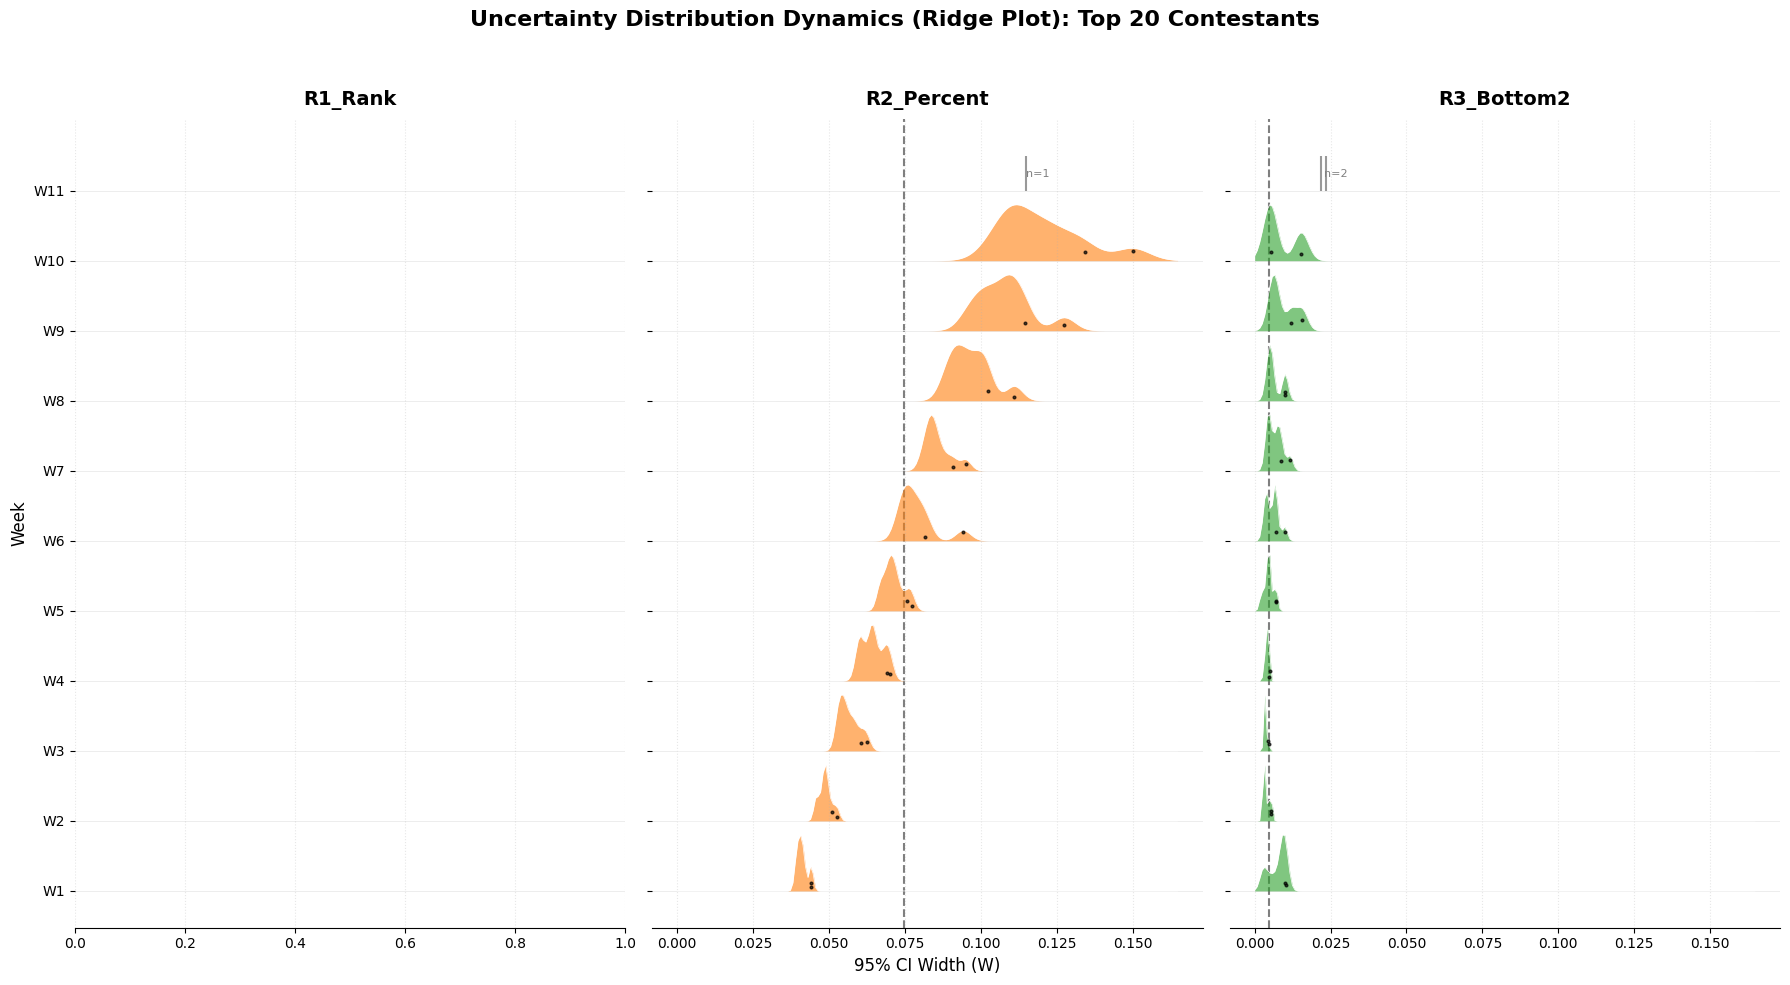

Ridge plot saved to: outputs/fig_ridgeline_rule_week_topbottom20_W.png
Ridge summary saved to: outputs/ridgeline_summary_topbottom20.csv

[Preview] Top 20 Contestants List:


,celebrity_name,overall_mean_W,group,n_weeks
0,Mario Lopez,0.0860,MostUncertain,10
1,Jason Taylor,0.0825,MostUncertain,10
2,Brooke Burke,0.0786,MostUncertain,10
3,Evan Lysacek,0.0783,MostUncertain,10
4,Kristi Yamaguchi,0.0774,MostUncertain,10



[Preview] Ridge Summary Data:


,rule_type,week,n_points,mean_W,median_W,p25_W,p75_W
0,R2_Percent,1,10,0.0412,0.0407,0.0399,0.0418
1,R2_Percent,2,10,0.0488,0.0488,0.0479,0.0495
2,R2_Percent,3,10,0.0565,0.0557,0.0541,0.0583
3,R2_Percent,4,10,0.0644,0.0643,0.0612,0.0670
4,R2_Percent,5,10,0.0712,0.0707,0.0695,0.0727


In [18]:
"""
=============================================================================
Supplementary Analysis: Rule × Week Uncertainty Ridge Plot (Top/Bottom 20)
=============================================================================
Visualizes uncertainty distributions across weeks for selected contestants
using ridgeline/joyplots, separated by rule type.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

# Ensure output directory exists (using global OUTPUT_DIR if defined, else default)
if 'OUTPUT_DIR' not in locals():
    OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_data(path):
    """Load and perform basic validation."""
    df = pd.read_csv(path)
    req = ['celebrity_name', 'week', 'rule_type', 'pV_ci_95_width']
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    
    # Filter valid weeks
    df = df[(df['week'] >= 1) & (df['week'] <= 11)].copy()
    return df

def select_topbottom20(df):
    """
    Selects Top 10 Most Uncertain + Bottom 10 Least Uncertain contestants.
    Returns:
        df20: Filtered DataFrame with only these 20 contestants
        df_list: Summary DataFrame of the 20 selected with their group
    """
    # 1. Aggregate to (name, week) level first (handle multi-season dups)
    # W -> mean
    # rule -> mode 
    # Use aggregation to ensure unique points
    df_agg = df.groupby(['celebrity_name', 'week']).agg({
        'pV_ci_95_width': 'mean',
        'rule_type': lambda x: sorted(x.mode())[0] if not x.mode().empty else x.iloc[0]
    }).reset_index()
    
    # 2. Compute contestant-level mean W
    df_cont = df_agg.groupby('celebrity_name')['pV_ci_95_width'].mean().reset_index()
    df_cont.columns = ['celebrity_name', 'mean_W']
    
    # Sort
    df_cont = df_cont.sort_values('mean_W', ascending=False)
    n = len(df_cont)
    
    if n <= 20:
        selected = df_cont.copy()
        selected['group'] = 'All'
    else:
        top10 = df_cont.head(10).copy()
        top10['group'] = 'MostUncertain'
        
        bot10 = df_cont.tail(10).copy()
        bot10['group'] = 'LeastUncertain'
        
        selected = pd.concat([top10, bot10])
    
    # 3. Filter original dataframe (but use aggregated version to avoid duplicates)
    # Re-merge group info
    df20 = df_agg[df_agg['celebrity_name'].isin(selected['celebrity_name'])].copy()
    df20 = df20.merge(selected[['celebrity_name', 'group']], on='celebrity_name', how='left')
    
    selected.rename(columns={'mean_W': 'overall_mean_W'}, inplace=True)
    # Count weeks
    counts = df20.groupby('celebrity_name')['week'].count().reset_index(name='n_weeks')
    df_list = selected.merge(counts, on='celebrity_name', how='left')
    
    return df20, df_list

def ridge_density(values, x_grid, bandwidth=None):
    """
    Compute KDE density on x_grid.
    Fallback to histogram smoothing if scipy fails or n < 2.
    """
    values = np.array(values)
    values = values[~np.isnan(values)] # Remove NaNs
    
    if len(values) < 2:
        return None # Not enough points for density
        
    try:
        kde = stats.gaussian_kde(values, bw_method=bandwidth)
        y = kde(x_grid)
        # Normalize to [0, 1] relative height for ridge plot visual
        if y.max() > 0:
            y = y / y.max()
        return y
    except Exception:
        # Fallback: Histogram + Rolling Mean
        hist, edges = np.histogram(values, bins=min(10, len(values)), density=True)
        centers = (edges[:-1] + edges[1:]) / 2
        # Interpolate to x_grid
        y_interp = np.interp(x_grid, centers, hist, left=0, right=0)
        # Smooth
        window = max(3, len(x_grid)//10)
        y_smooth = pd.Series(y_interp).rolling(window, center=True, min_periods=1).mean().values
        if y_smooth.max() > 0:
            y_smooth = y_smooth / y_smooth.max()
        return y_smooth

def plot_ridgeline_innovative(df20, outpath=None):
    """
    Plots the RIDGE PLOT (1x3 Rules) with Innovative Features:
    A) Outlier dots ('Top 2' max W) on each ridge
    """
    rules = ['R1_Rank', 'R2_Percent', 'R3_Bottom2']
    weeks = sorted(df20['week'].unique())
    
    # Setup X-Grid for KDE
    min_w, max_w = df20['pV_ci_95_width'].min(), df20['pV_ci_95_width'].max()
    x_pad = (max_w - min_w) * 0.1
    x_grid = np.linspace(max(0, min_w - x_pad), max_w + x_pad, 200)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 10), sharey=True)
    
    # Store summary stats for export
    summary_data = []
    
    for ax, rule in zip(axes, rules):
        # Subset for Rule
        df_rule = df20[df20['rule_type'] == rule]
        
        # Rule specific median (vertical line)
        if not df_rule.empty:
            rule_median = df_rule['pV_ci_95_width'].median()
            ax.axvline(rule_median, color='black', linestyle='--', alpha=0.5, zorder=0, label='Rule Median')
        
        # Iterate Weeks (Draw form bottom up: Week 1 at bottom, Week 11 at top)
        # Traditionally ridgelines stack upwards.
        for week in weeks:
            data = df_rule[df_rule['week'] == week]['pV_ci_95_width'].values
            n = len(data)
            
            # Save stats
            if n > 0:
                summary_data.append({
                    'rule_type': rule, 'week': week, 'n_points': n,
                    'mean_W': np.mean(data), 'median_W': np.median(data),
                    'p25_W': np.percentile(data, 25), 'p75_W': np.percentile(data, 75)
                })
            
            # Base y position = week number
            base_y = week
            
            if n < 3:
                # Rug plot fallback
                if n > 0:
                    ax.vlines(data, base_y, base_y + 0.5, color='gray', lw=1.5, alpha=0.8)
                    ax.text(np.mean(data), base_y + 0.2, f"n={n}", fontsize=8, color='gray')
            else:
                # KDE
                y_dens = ridge_density(data, x_grid, bandwidth=0.4) # Slightly smoother KDE
                if y_dens is not None:
                    # Scale height (e.g. max height 0.8 units so they don't overlap too much)
                    scaled_y = y_dens * 0.8
                    
                    # Fill
                    # Use distinct colors per rule
                    colors = {'R1_Rank': '#1f77b4', 'R2_Percent': '#ff7f0e', 'R3_Bottom2': '#2ca02c'}
                    c = colors.get(rule, 'gray')
                    
                    # Gradient alpha based on week intensity or just solid with alpha
                    ax.fill_between(x_grid, base_y, base_y + scaled_y, color=c, alpha=0.6, lw=0)
                    ax.plot(x_grid, base_y + scaled_y, color='white', lw=0.5)
                    
                    # INNOVATION A: "Heavy Tail Visualization"
                    # Overlay Top 2 largest values as outlier dots with slight jitter
                    top2 = np.sort(data)[-2:]
                    jitter = np.random.uniform(-0.05, 0.05, len(top2))
                    ax.scatter(top2, np.full_like(top2, base_y) + jitter + 0.1, 
                               s=15, color='black', alpha=0.7, zorder=5, marker='.')

        # Subplot Polish
        ax.set_title(f"{rule}", fontsize=14, fontweight='bold', pad=10)
        ax.set_yticks(weeks)
        ax.set_yticklabels([f"W{w}" for w in weeks])
        ax.grid(axis='x', linestyle=':', alpha=0.3)
        if rule == rules[1]:
            ax.set_xlabel('95% CI Width (W)', fontsize=12)
        
        # Cosmetic: Remove top/right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False) # Clean look
        
        # Grid lines for weeks
        for w in weeks:
            ax.axhline(w, color='gray', lw=0.5, alpha=0.2, zorder=0)

    # Global Title
    fig.suptitle('Uncertainty Distribution Dynamics (Ridge Plot): Top 20 Contestants', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Manual Y-label on first axes
    axes[0].set_ylabel('Week', fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    if outpath:
        fig.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, pd.DataFrame(summary_data)


# =============================================================================
# Execution Block
# =============================================================================
try:
    print("Generating Ridge Plot...")
    
    # 1. Load
    df_raw = load_data('data/q1_bootstrap_uncertainty.csv')
    
    # 2. Select Top/Bottom 20
    df20_filt, df20_list = select_topbottom20(df_raw)
    
    # Export 20 list
    path_list = OUTPUT_DIR / 'topbottom20_list.csv'
    df20_list.to_csv(path_list, index=False)
    print(f"Top 20 list saved to: {path_list}")
    
    # 3. Plot Ridge
    path_fig = OUTPUT_DIR / 'fig_ridgeline_rule_week_topbottom20_W.png'
    fig_ridge, df_ridge_summ = plot_ridgeline_innovative(df20_filt, path_fig)
    print(f"Ridge plot saved to: {path_fig}")
    
    # 4. Save Summary
    path_summ = OUTPUT_DIR / 'ridgeline_summary_topbottom20.csv'
    df_ridge_summ.to_csv(path_summ, index=False)
    print(f"Ridge summary saved to: {path_summ}")

    # Display Previews
    print("\n[Preview] Top 20 Contestants List:")
    display(df20_list.sort_values('overall_mean_W', ascending=False).head(5))
    print("\n[Preview] Ridge Summary Data:")
    display(df_ridge_summ.head())

except Exception as e:
    print(f"Error generating ridge plot: {e}")
    import traceback
    traceback.print_exc()

<>:112: SyntaxWarning: invalid escape sequence '\p'
<>:112: SyntaxWarning: invalid escape sequence '\p'
/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/1542132041.py:112: SyntaxWarning: invalid escape sequence '\p'
  ax_bubble.set_title("Consistency Timeline (Bubble Size $\propto$ Vote Share)", fontsize=14, fontweight='bold', pad=15)


Combined dashboard saved to: outputs/fig_combined_dashboard_top5_bottom5.png


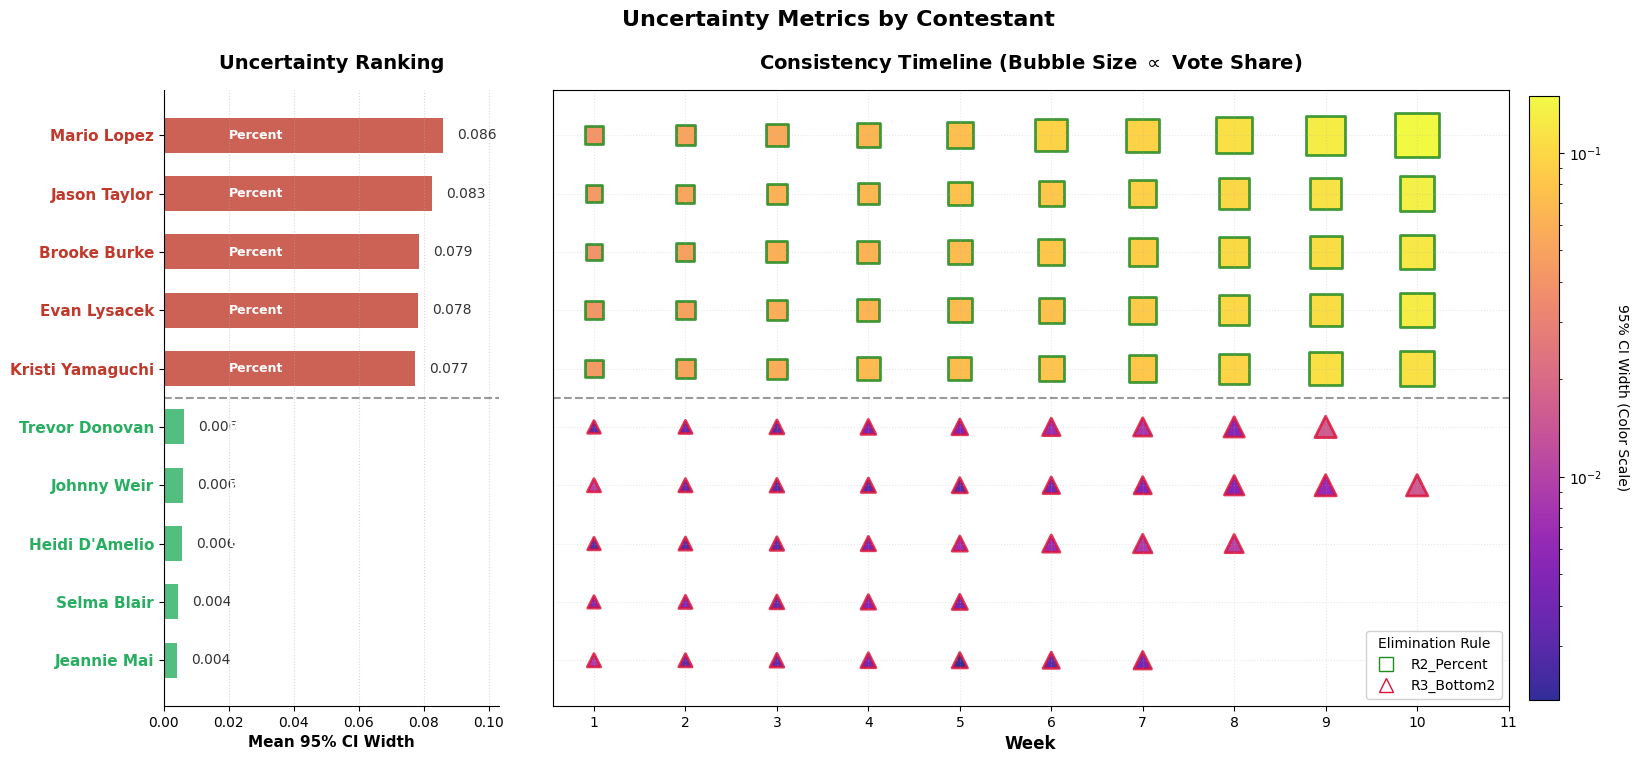

In [19]:
"""
=============================================================================
Supplementary Analysis: Combined Dashboard (Bar Chart + Bubble Heatmap)
=============================================================================
Merges the Uncertainty Ranking (Bar Chart) and Temporal Evolution (Bubble Heatmap)
into a single composite figure for side-by-side comparison of Top 5 vs Bottom 5.
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

def plot_combined_dashboard(df_plot, df_rank, outpath):
    """
    Creates a composite figure:
    - Left Panel: Horizontal Bar Chart of Mean CI Width (The "Rule" of Ranking)
    - Right Panel: Bubble Heatmap of Weekly Evolution (The "Timeline")
    """
    # 1. Prepare Data Sorting (Same as Bubble Plot)
    # Sort ascending (Least Uncertain at bottom/index 0, Most Uncertain at top)
    df_sorted = df_rank.sort_values('mean_W', ascending=True).reset_index(drop=True)
    df_sorted['y_pos'] = df_sorted.index
    
    # Map y_pos to timeline data
    name_to_y = pd.Series(df_sorted.y_pos.values, index=df_sorted.celebrity_name).to_dict()
    df_plot_c = df_plot.copy()
    df_plot_c['y_pos'] = df_plot_c['celebrity_name'].map(name_to_y)
    
    # 2. Setup Figure with GridSpec
    fig = plt.figure(figsize=(18, 8)) # Wide figure
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 3], wspace=0.08)
    
    ax_bar = fig.add_subplot(gs[0])
    ax_bubble = fig.add_subplot(gs[1], sharey=ax_bar) # Share Y axis to align names
    
    # =========================================================================
    # LEFT PANEL: RANKING BAR CHART
    # =========================================================================
    # Colors based on group
    bar_colors = df_sorted['group'].map({'MostUncertain': '#C0392B', 'LeastUncertain': '#27AE60'}).fillna('gray')
    
    # Bar Chart
    bars = ax_bar.barh(df_sorted['y_pos'], df_sorted['mean_W'], height=0.6, color=bar_colors, alpha=0.8)
    
    # Add Value Labels inside/outside bar
    max_w = df_sorted['mean_W'].max()
    for bar in bars:
        width = bar.get_width()
        # Position text slightly after bar end
        ax_bar.text(width + max_w*0.05, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
                    va='center', fontsize=10, color='#333333', fontweight='normal')
    
    # Styling Left Panel
    ax_bar.set_xlabel('Mean 95% CI Width', fontsize=11, fontweight='bold')
    
    # Y-Tick Labels (Names) - We put these on the LEFT of the bar chart
    lbls_names = list(df_sorted['celebrity_name'])
    ax_bar.set_yticks(df_sorted['y_pos'])
    ax_bar.set_yticklabels(lbls_names, fontsize=11)
    
    # Color Y-labels
    for y, grp in zip(df_sorted['y_pos'], df_sorted['group']):
        color = '#C0392B' if grp == 'MostUncertain' else '#27AE60'
        ax_bar.get_yticklabels()[int(y)].set_color(color)
        ax_bar.get_yticklabels()[int(y)].set_fontweight('bold')
        
    ax_bar.grid(axis='x', linestyle=':', alpha=0.5)
    ax_bar.set_title("Uncertainty Ranking", fontsize=14, fontweight='bold', pad=15)
    
    # Remove top/right spines
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.set_xlim(0, max_w * 1.2) # Pad for text
    
    # =========================================================================
    # RIGHT PANEL: BUBBLE HEATMAP (Reusing Logic)
    # =========================================================================
    # Compute Sizes
    p_min, p_max = df_plot_c['pV_mean'].min(), df_plot_c['pV_mean'].max()
    df_plot_c['size_scaled'] = (df_plot_c['pV_mean'] - p_min) / (p_max - p_min + 1e-9)
    sizes = 80 + 900 * df_plot_c['size_scaled']
    
    # Metrics
    cmap = plt.cm.plasma
    norm = mcolors.LogNorm(vmin=df_plot_c['pV_ci_95_width'].min() + 1e-6, 
                           vmax=df_plot_c['pV_ci_95_width'].max())
    
    marker_map = {'R1_Rank': 'o', 'R2_Percent': 's', 'R3_Bottom2': '^'}
    edge_map =   {'R1_Rank': 'navy', 'R2_Percent': 'forestgreen', 'R3_Bottom2': 'crimson'}
    
    unique_rules = df_plot_c['rule_type'].unique()
    plotted_rules = []
    
    sc = None
    for r_type in unique_rules:
        subset = df_plot_c[df_plot_c['rule_type'] == r_type]
        if subset.empty: continue
        sc = ax_bubble.scatter(
            subset['week'], subset['y_pos'], 
            s=sizes[subset.index], c=subset['pV_ci_95_width'], 
            cmap=cmap, norm=norm, marker=marker_map.get(r_type,'o'),
            edgecolors=edge_map.get(r_type,'#333'), linewidth=2, alpha=0.85, label=r_type
        )
        plotted_rules.append(r_type)
        
    # Styling Right Panel
    ax_bubble.set_xlabel('Week', fontsize=12, fontweight='bold')
    ax_bubble.set_xticks(range(1, 12))
    ax_bubble.grid(True, linestyle=':', alpha=0.3)
    ax_bubble.set_title("Consistency Timeline (Bubble Size $\propto$ Vote Share)", fontsize=14, fontweight='bold', pad=15)
    
    # Hide Y-ticks on right plot (Shared) - But display Rule Types as secondary axis or text?
    # User wanted rule types displayed. Let's put them on the right side of the bubble plot?
    # Or keep them under the names on the left (but that was the previous request).
    # Since we have a dedicated panel now, we can put names on left, and maybe Rule Type as text on the bar chart?
    # Let's add Rule Type as annotations on the Bar Chart bars
    for i, row in df_sorted.iterrows():
        rule_short = row['dominant_rule_type'].replace('R1_', '').replace('R2_', '').replace('R3_', '')
        ax_bar.text(0.02, i, rule_short, color='white', va='center', fontweight='bold', fontsize=9)
    
    plt.setp(ax_bubble.get_yticklabels(), visible=False)
    ax_bubble.tick_params(left=False) # Remove ticks
    
    # Separator Line
    if len(df_sorted[df_sorted.group=='LeastUncertain']) == 5:
        split_y = 4.5
        ax_bar.axhline(split_y, color='k', linestyle='--', alpha=0.4)
        ax_bubble.axhline(split_y, color='k', linestyle='--', alpha=0.4)

    # Colorbar
    cbar = plt.colorbar(sc, ax=ax_bubble, fraction=0.03, pad=0.02)
    cbar.set_label('95% CI Width (Color Scale)', rotation=270, labelpad=20)
    
    # Legend
    handles = []
    for r in sorted(plotted_rules):
        handles.append(mlines.Line2D([],[], color='w', marker=marker_map.get(r), 
                                     markeredgecolor=edge_map.get(r), label=r, markersize=10))
    ax_bubble.legend(handles=handles, title='Elimination Rule', loc='lower right', framealpha=0.9)
    
    plt.suptitle("Uncertainty Metrics by Contestant", fontsize=16, fontweight='bold', y=0.98)
    
    if outpath:
        fig.savefig(outpath, dpi=600, bbox_inches='tight')
        print(f"Combined dashboard saved to: {outpath}")
    
    plt.show()

# Execution
try:
    if 'df_rank_final' not in locals():
        print("Regenerating data...")
        # Assuming prepare_topbottom5 is defined in previous cells
        if 'df_source' not in locals():
            df_source = pd.read_csv('data/q1_bootstrap_uncertainty.csv')
        df_plot_final, df_rank_final = prepare_topbottom5(df_source)

    final_out = OUTPUT_DIR / 'fig_combined_dashboard_top5_bottom5.png'
    plot_combined_dashboard(df_plot_final, df_rank_final, final_out)
    
except Exception as e:
    print(f"Error plotting combined dashboard: {e}")
    import traceback
    traceback.print_exc()

---
## Part 4: Uncertainty Factor Attribution Analysis

This section analyzes **what drives vote share uncertainty** — whether it stems from:
- **Contestant characteristics** (industry, age, popularity trends, judge scores)
- **Competition rules** (R1_Rank, R2_Percent, R3_Bottom2)
- **Week progression** (early vs late weeks, number of contestants alive)

We use exploratory data analysis, correlation analysis, ANOVA/Kruskal-Wallis tests, and regression modeling to decompose variance and attribute uncertainty sources.

In [20]:
# ============================================================
# Step 1: Merge datasets - Join uncertainty with contestant features
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Load uncertainty data
df_unc = pd.read_csv(DATA_PATH)
print(f"Uncertainty data: {df_unc.shape[0]} rows, {df_unc.shape[1]} columns")

# Load contestant features
df_features = pd.read_csv("data/processed_with_trends.csv")
print(f"Features data: {df_features.shape[0]} rows, {df_features.shape[1]} columns")

# Merge on (season, week, celebrity_name)
df_merged = df_unc.merge(
    df_features[['season', 'week', 'celebrity_name', 
                 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry_region',
                 'celebrity_age_during_season', 'ballroom_partner',
                 'j_total', 'j_mean', 'j_sd', 'j_rank', 'j_pct', 'j_z_within_week', 'delta_j_total',
                 'trend_used', 'trend_preday', 'n_alive_w', 'season_len', 'placement']],
    on=['season', 'week', 'celebrity_name'],
    how='left'
)

print(f"\nMerged data: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")
print(f"Missing after merge: {df_merged['celebrity_industry'].isna().sum()} rows")

# Display sample
df_merged.head()

Uncertainty data: 2777 rows, 18 columns
Features data: 4631 rows, 40 columns

Merged data: 2777 rows, 35 columns
Missing after merge: 0 rows


,season,week,celebrity_name,pV_mean,pV_median,pV_std,pV_cv,pV_ci_2.5,pV_ci_97.5,pV_ci_95_width,pV_ci_1.5,pV_ci_98.5,pV_ci_97_width,n_bootstrap_samples,rule_type,pV_hat,elim_prob,eliminated_end_of_week,celebrity_industry,celebrity_homestate,celebrity_homecountry_region,celebrity_age_during_season,ballroom_partner,j_total,j_mean,j_sd,j_rank,j_pct,j_z_within_week,delta_j_total,trend_used,trend_preday,n_alive_w,season_len,placement
0,8,1,Belinda Carlisle,0.0605,0.0603,0.0049,0.0811,0.0517,0.0697,0.0180,0.0500,0.0698,0.0199,102,R2_Percent,0.0152,0.1116,False,Singer/Rapper,California,United States,50,Jonathan Roberts,17.0000,5.6667,0.5774,9.5000,0.0700,-0.4941,NaN,7.0000,NaN,13,11,13
1,8,1,Chuck Wicks,0.0789,0.0785,0.0070,0.0881,0.0666,0.0941,0.0276,0.0652,0.0948,0.0297,102,R2_Percent,0.0696,0.0703,False,Singer/Rapper,Delaware,United States,29,Julianne Hough,20.0000,6.6667,0.5774,5.0000,0.0823,0.3818,NaN,23.0000,NaN,13,11,6
2,8,1,David Alan Grier,0.0694,0.0693,0.0066,0.0944,0.0578,0.0818,0.0240,0.0573,0.0820,0.0247,102,R2_Percent,0.0247,0.0988,False,Actor/Actress,Michigan,United States,52,Kym Johnson,19.0000,6.3333,0.5774,6.0000,0.0782,0.0898,NaN,0.0000,NaN,13,11,9
3,8,1,Denise Richards,0.0685,0.0686,0.0066,0.0970,0.0570,0.0831,0.0261,0.0548,0.0869,0.0320,102,R2_Percent,0.0170,0.1072,False,Actor/Actress,Illinois,United States,38,Maksim Chmerkoskiy,18.0000,6.0000,0.0000,7.5000,0.0741,-0.2021,NaN,16.0000,NaN,13,11,12
4,8,1,Gilles Marini,0.0877,0.0871,0.0084,0.0961,0.0728,0.1045,0.0318,0.0711,0.1067,0.0356,102,R2_Percent,0.1651,0.0324,False,Actor/Actress,NaN,France,33,Cheryl Burke,24.0000,8.0000,0.0000,1.0000,0.0988,1.5497,NaN,11.0000,NaN,13,11,2


/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/3490755761.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='rule_type', y='pV_ci_95_width', order=order_rule, ax=ax, palette='Set2')
/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/3490755761.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='week', y='pV_ci_95_width', ax=ax, palette='coolwarm')
/var/folders/0m/2sbyxxc10czg8dp3clzyzxym0000gn/T/ipykernel_80717/3490755761.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.box

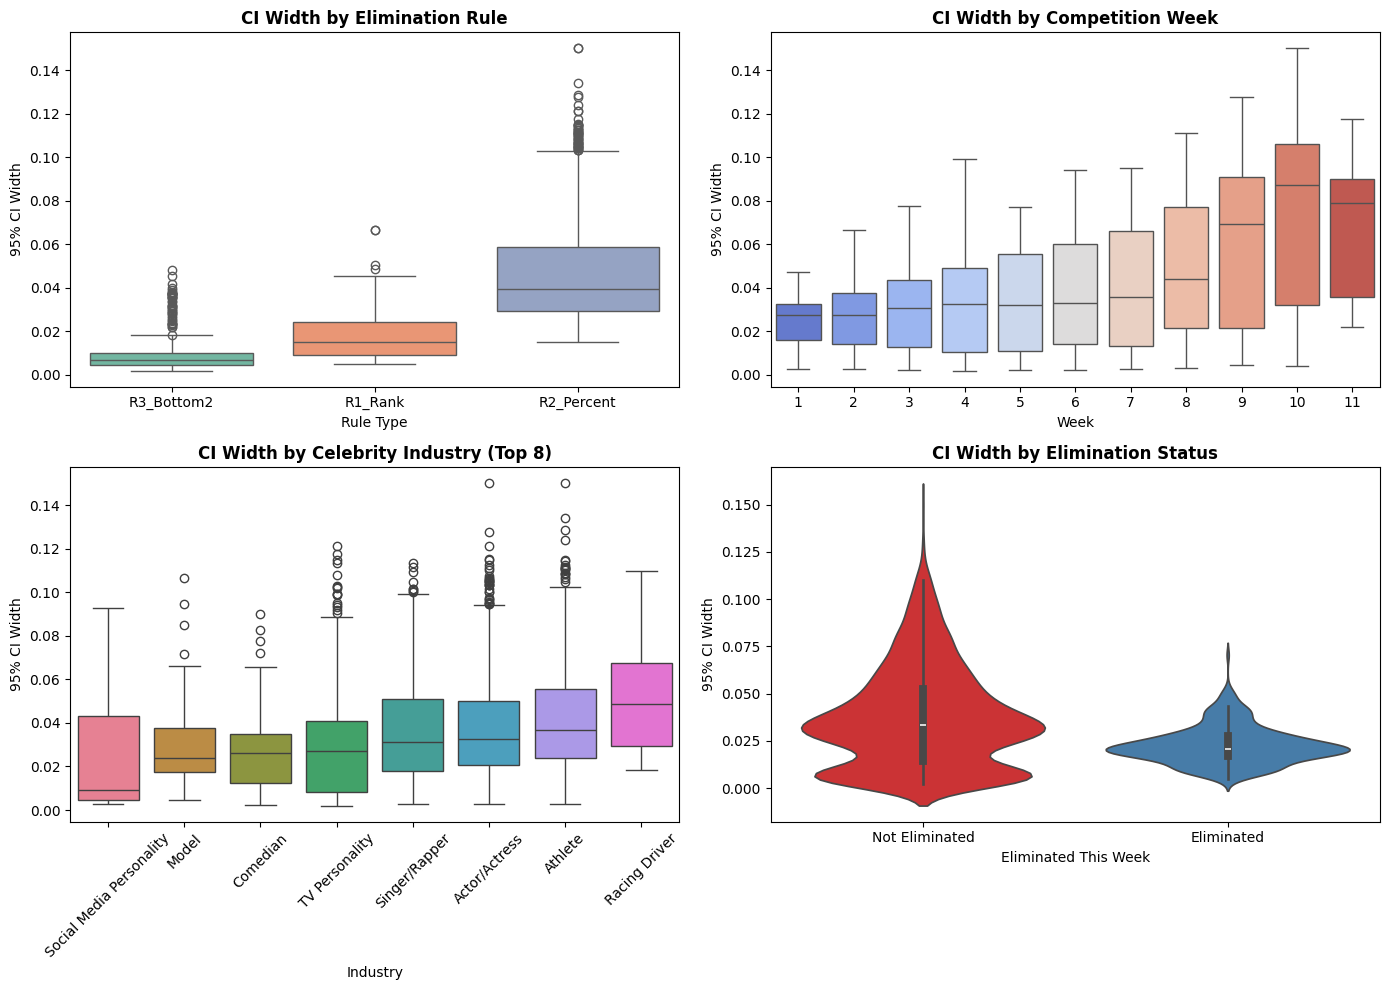

✅ Factor boxplots saved to outputs/fig_factor_boxplots.png


In [21]:
# ============================================================
# Step 2: Exploratory Visualization - Uncertainty by Categorical Factors
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2.1 By Rule Type
ax = axes[0, 0]
order_rule = df_merged.groupby('rule_type')['pV_ci_95_width'].median().sort_values().index
sns.boxplot(data=df_merged, x='rule_type', y='pV_ci_95_width', order=order_rule, ax=ax, palette='Set2')
ax.set_title('CI Width by Elimination Rule', fontsize=12, fontweight='bold')
ax.set_xlabel('Rule Type')
ax.set_ylabel('95% CI Width')

# 2.2 By Week
ax = axes[0, 1]
sns.boxplot(data=df_merged, x='week', y='pV_ci_95_width', ax=ax, palette='coolwarm')
ax.set_title('CI Width by Competition Week', fontsize=12, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('95% CI Width')

# 2.3 By Industry (Top 8)
ax = axes[1, 0]
top_industries = df_merged['celebrity_industry'].value_counts().head(8).index
df_ind = df_merged[df_merged['celebrity_industry'].isin(top_industries)]
order_ind = df_ind.groupby('celebrity_industry')['pV_ci_95_width'].median().sort_values().index
sns.boxplot(data=df_ind, x='celebrity_industry', y='pV_ci_95_width', order=order_ind, ax=ax, palette='husl')
ax.set_title('CI Width by Celebrity Industry (Top 8)', fontsize=12, fontweight='bold')
ax.set_xlabel('Industry')
ax.set_ylabel('95% CI Width')
ax.tick_params(axis='x', rotation=45)

# 2.4 By Elimination Status
ax = axes[1, 1]
sns.violinplot(data=df_merged, x='eliminated_end_of_week', y='pV_ci_95_width', ax=ax, palette='Set1')
ax.set_title('CI Width by Elimination Status', fontsize=12, fontweight='bold')
ax.set_xlabel('Eliminated This Week')
ax.set_ylabel('95% CI Width')
ax.set_xticklabels(['Not Eliminated', 'Eliminated'])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_factor_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Factor boxplots saved to outputs/fig_factor_boxplots.png")

Correlation analysis on 2777 complete cases, 13 features

=== Correlations with CI Width (sorted by |Spearman ρ|) ===


,Feature,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Significant
9,pV_hat,0.732,0.00e+00,0.609,8.26e-282,True
5,j_pct,0.641,7.81e-322,0.524,1.88e-195,True
1,n_alive_w,-0.585,7.03e-255,-0.492,1.65e-169,True
2,j_mean,0.415,4.16e-116,0.380,3.82e-96,True
4,j_rank,-0.396,5.75e-105,-0.369,2.48e-90,True
0,week,0.442,4.11e-133,0.320,2.58e-67,True
8,celebrity_age_during_season,-0.243,1.28e-38,-0.247,5.64e-40,True
6,j_z_within_week,0.162,8.62e-18,0.165,1.77e-18,True
7,trend_used,-0.091,1.71e-06,-0.085,6.67e-06,True
10,elim_prob,0.080,2.39e-05,0.042,2.69e-02,False


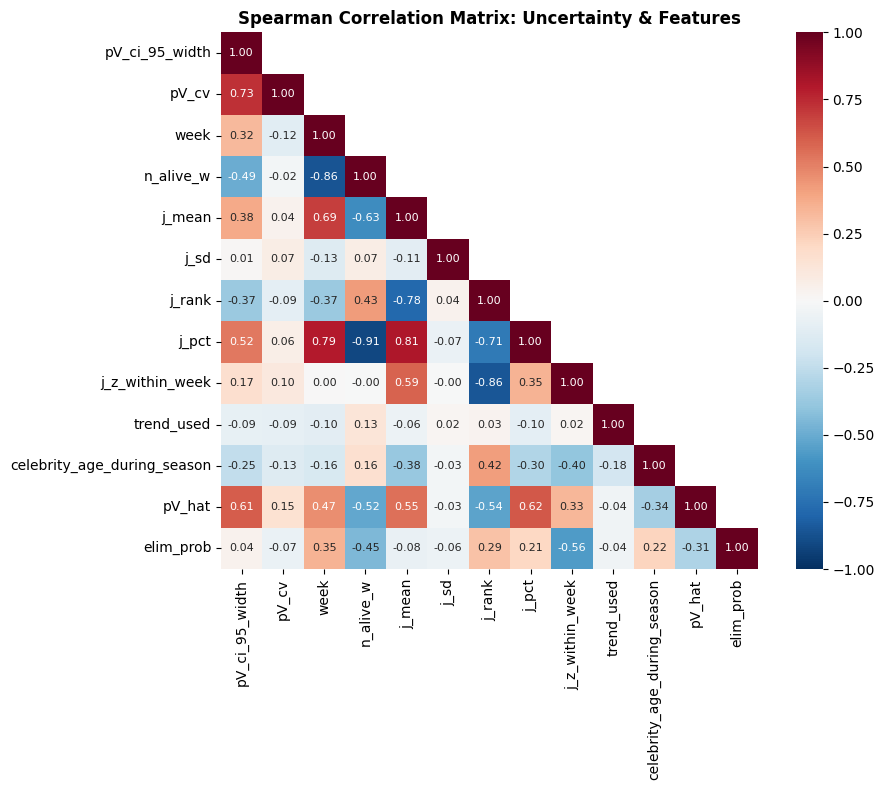


✅ Correlation heatmap saved to outputs/fig_correlation_heatmap.png


In [22]:
# ============================================================
# Step 3: Correlation Analysis - Numeric Features vs Uncertainty
# ============================================================

# Define numeric features for correlation
numeric_features = [
    'pV_ci_95_width', 'pV_cv',  # Uncertainty metrics
    'week', 'n_alive_w',  # Competition structure
    'j_mean', 'j_sd', 'j_rank', 'j_pct', 'j_z_within_week',  # Judge scores
    'trend_used',  # Popularity trends
    'celebrity_age_during_season',  # Demographics
    'pV_hat', 'elim_prob'  # Model predictions
]

# Filter to available columns
available_features = [c for c in numeric_features if c in df_merged.columns]
df_corr = df_merged[available_features].dropna()

print(f"Correlation analysis on {len(df_corr)} complete cases, {len(available_features)} features\n")

# Compute Pearson and Spearman correlations with CI width
corr_results = []
for feat in available_features:
    if feat in ['pV_ci_95_width', 'pV_cv']:
        continue
    
    # Pearson
    r_pearson, p_pearson = stats.pearsonr(df_corr['pV_ci_95_width'], df_corr[feat])
    # Spearman
    r_spearman, p_spearman = stats.spearmanr(df_corr['pV_ci_95_width'], df_corr[feat])
    
    corr_results.append({
        'Feature': feat,
        'Pearson_r': r_pearson,
        'Pearson_p': p_pearson,
        'Spearman_rho': r_spearman,
        'Spearman_p': p_spearman,
        'Significant': p_spearman < 0.001
    })

corr_df = pd.DataFrame(corr_results).sort_values('Spearman_rho', key=abs, ascending=False)
print("=== Correlations with CI Width (sorted by |Spearman ρ|) ===")
display(corr_df.style.format({
    'Pearson_r': '{:.3f}', 'Pearson_p': '{:.2e}',
    'Spearman_rho': '{:.3f}', 'Spearman_p': '{:.2e}'
}).background_gradient(subset=['Spearman_rho'], cmap='RdBu_r', vmin=-1, vmax=1))

# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_corr[available_features].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlation Matrix: Uncertainty & Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Correlation heatmap saved to outputs/fig_correlation_heatmap.png")

=== Kruskal-Wallis / Mann-Whitney U Tests for Categorical Factors ===
Effect size interpretation: η² < 0.01 (small), 0.01-0.06 (medium), > 0.14 (large)



,Factor,H-statistic,p-value,η²,n_groups
4,season,1546.8,1.54e-304,0.4222,34
0,rule_type,1513.8,0.00e+00,0.4069,3
3,eliminated_end_of_week,nan,1.64e-20,0.3311,2
1,week,329.3,9.73e-65,0.2246,11
2,celebrity_industry,237.3,1.13e-39,0.0725,20


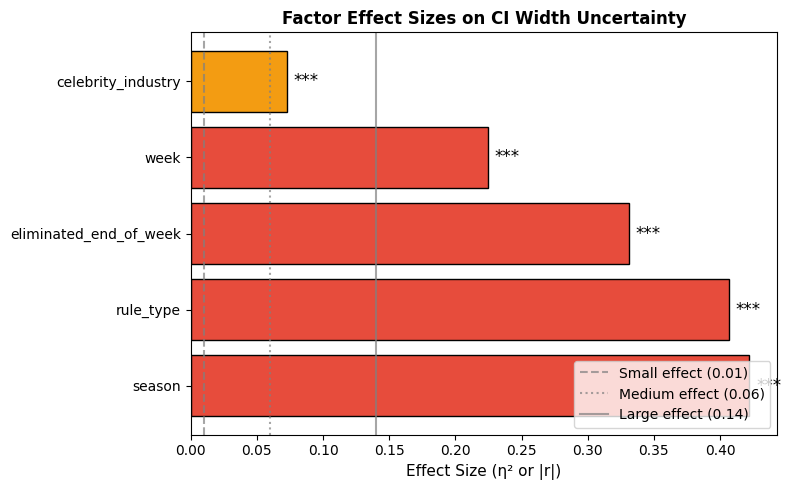


✅ Effect size chart saved to outputs/fig_effect_sizes.png


In [23]:
# ============================================================
# Step 4: ANOVA / Kruskal-Wallis Tests for Categorical Factors
# ============================================================
from scipy.stats import kruskal, mannwhitneyu, f_oneway

def compute_eta_squared(groups, overall_mean, overall_n):
    """Compute eta-squared (η²) effect size for ANOVA"""
    ss_between = sum(len(g) * (g.mean() - overall_mean)**2 for g in groups)
    ss_total = sum(((g - overall_mean)**2).sum() for g in groups)
    return ss_between / ss_total if ss_total > 0 else 0

def compute_epsilon_squared(H, n):
    """Compute epsilon-squared (ε²) effect size for Kruskal-Wallis"""
    return (H - len(set(groups)) + 1) / (n - 1) if n > 1 else 0

anova_results = []

# 4.1 Test by Rule Type
groups = [g['pV_ci_95_width'].values for _, g in df_merged.groupby('rule_type')]
H, p_kw = kruskal(*groups)
eta2 = compute_eta_squared(groups, df_merged['pV_ci_95_width'].mean(), len(df_merged))
anova_results.append({'Factor': 'rule_type', 'H-statistic': H, 'p-value': p_kw, 'η²': eta2, 'n_groups': 3})

# 4.2 Test by Week
groups = [g['pV_ci_95_width'].values for _, g in df_merged.groupby('week')]
H, p_kw = kruskal(*groups)
eta2 = compute_eta_squared(groups, df_merged['pV_ci_95_width'].mean(), len(df_merged))
anova_results.append({'Factor': 'week', 'H-statistic': H, 'p-value': p_kw, 'η²': eta2, 'n_groups': df_merged['week'].nunique()})

# 4.3 Test by Industry
groups = [g['pV_ci_95_width'].values for _, g in df_merged.groupby('celebrity_industry') if len(g) >= 10]
H, p_kw = kruskal(*groups)
eta2 = compute_eta_squared(groups, df_merged['pV_ci_95_width'].mean(), len(df_merged))
anova_results.append({'Factor': 'celebrity_industry', 'H-statistic': H, 'p-value': p_kw, 'η²': eta2, 'n_groups': len(groups)})

# 4.4 Test by Elimination Status
g1 = df_merged[df_merged['eliminated_end_of_week'] == True]['pV_ci_95_width']
g2 = df_merged[df_merged['eliminated_end_of_week'] == False]['pV_ci_95_width']
U, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
# Rank-biserial correlation as effect size
n1, n2 = len(g1), len(g2)
r_rb = 1 - (2*U) / (n1 * n2)
anova_results.append({'Factor': 'eliminated_end_of_week', 'H-statistic': np.nan, 'p-value': p_mw, 'η²': abs(r_rb), 'n_groups': 2})

# 4.5 Test by Season
groups = [g['pV_ci_95_width'].values for _, g in df_merged.groupby('season')]
H, p_kw = kruskal(*groups)
eta2 = compute_eta_squared(groups, df_merged['pV_ci_95_width'].mean(), len(df_merged))
anova_results.append({'Factor': 'season', 'H-statistic': H, 'p-value': p_kw, 'η²': eta2, 'n_groups': df_merged['season'].nunique()})

anova_df = pd.DataFrame(anova_results).sort_values('η²', ascending=False)
print("=== Kruskal-Wallis / Mann-Whitney U Tests for Categorical Factors ===")
print("Effect size interpretation: η² < 0.01 (small), 0.01-0.06 (medium), > 0.14 (large)\n")
display(anova_df.style.format({
    'H-statistic': '{:.1f}', 'p-value': '{:.2e}', 'η²': '{:.4f}'
}).background_gradient(subset=['η²'], cmap='Oranges'))

# Visualize effect sizes
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if x > 0.14 else '#f39c12' if x > 0.06 else '#3498db' for x in anova_df['η²']]
bars = ax.barh(anova_df['Factor'], anova_df['η²'], color=colors, edgecolor='black')
ax.axvline(0.01, color='gray', linestyle='--', alpha=0.7, label='Small effect (0.01)')
ax.axvline(0.06, color='gray', linestyle=':', alpha=0.7, label='Medium effect (0.06)')
ax.axvline(0.14, color='gray', linestyle='-', alpha=0.7, label='Large effect (0.14)')
ax.set_xlabel('Effect Size (η² or |r|)', fontsize=11)
ax.set_title('Factor Effect Sizes on CI Width Uncertainty', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')

for bar, p in zip(bars, anova_df['p-value']):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, sig, va='center', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Effect size chart saved to outputs/fig_effect_sizes.png")

In [24]:
# ============================================================
# Step 5: Multivariate Regression - Decompose Uncertainty Sources
# ============================================================
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Prepare regression data
df_reg = df_merged.copy()

# Encode categorical variables
df_reg['rule_R2'] = (df_reg['rule_type'] == 'R2_Percent').astype(int)
df_reg['rule_R3'] = (df_reg['rule_type'] == 'R3_Bottom2').astype(int)

# Top industries as dummies
top_ind = ['Actor/Actress', 'Athlete', 'Singer/Rapper', 'TV Personality']
for ind in top_ind:
    df_reg[f'ind_{ind.replace("/", "_").replace(" ", "_")}'] = (df_reg['celebrity_industry'] == ind).astype(int)

# Feature groups
structural_features = ['week', 'n_alive_w', 'rule_R2', 'rule_R3']  # Competition structure
contestant_features = ['j_mean', 'j_z_within_week', 'trend_used', 'celebrity_age_during_season', 'pV_hat']  # Contestant traits
industry_features = [f'ind_{ind.replace("/", "_").replace(" ", "_")}' for ind in top_ind]

all_features = structural_features + contestant_features + industry_features

# Drop missing values
df_reg_clean = df_reg[['pV_ci_95_width'] + all_features].dropna()
print(f"Regression on {len(df_reg_clean)} observations, {len(all_features)} features\n")

# Standardize for comparable coefficients
X = df_reg_clean[all_features]
y = df_reg_clean['pV_ci_95_width']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=all_features, index=X.index)
X_scaled = sm.add_constant(X_scaled)

# Fit OLS regression
model = sm.OLS(y, X_scaled).fit()

print("=== OLS Regression: Predicting CI Width from All Features ===")
print(f"R² = {model.rsquared:.4f}, Adjusted R² = {model.rsquared_adj:.4f}")
print(f"F-statistic = {model.fvalue:.1f}, p = {model.f_pvalue:.2e}\n")

# Extract standardized coefficients
coef_df = pd.DataFrame({
    'Feature': all_features,
    'β (standardized)': model.params[1:].values,
    'Std Error': model.bse[1:].values,
    't-stat': model.tvalues[1:].values,
    'p-value': model.pvalues[1:].values,
    'Significant': model.pvalues[1:].values < 0.05
}).sort_values('β (standardized)', key=abs, ascending=False)

# Categorize features
def categorize_feature(f):
    if f in structural_features:
        return 'Structural (Rule/Week)'
    elif f in contestant_features:
        return 'Contestant Trait'
    else:
        return 'Industry'

coef_df['Category'] = coef_df['Feature'].apply(categorize_feature)

print("=== Standardized Coefficients (sorted by |β|) ===")
display(coef_df.style.format({
    'β (standardized)': '{:.4f}', 'Std Error': '{:.4f}',
    't-stat': '{:.2f}', 'p-value': '{:.3e}'
}).background_gradient(subset=['β (standardized)'], cmap='RdBu_r', vmin=-0.5, vmax=0.5))

Regression on 2777 observations, 13 features

=== OLS Regression: Predicting CI Width from All Features ===
R² = 0.8960, Adjusted R² = 0.8955
F-statistic = 1830.7, p = 0.00e+00

=== Standardized Coefficients (sorted by |β|) ===


,Feature,β (standardized),Std Error,t-stat,p-value,Significant,Category
2,rule_R2,0.0175,0.0005,34.84,9.445e-221,True,Structural (Rule/Week)
8,pV_hat,0.0164,0.0002,76.64,0.000e+00,True,Contestant Trait
0,week,0.0043,0.0005,8.71,5.275e-18,True,Structural (Rule/Week)
4,j_mean,-0.0029,0.0004,-7.98,2.109e-15,True,Contestant Trait
3,rule_R3,0.0022,0.0006,3.90,9.862e-05,True,Structural (Rule/Week)
5,j_z_within_week,0.0014,0.0003,4.98,6.886e-07,True,Contestant Trait
1,n_alive_w,-0.0011,0.0005,-2.32,2.055e-02,True,Structural (Rule/Week)
6,trend_used,0.0009,0.0002,5.33,1.034e-07,True,Contestant Trait
9,ind_Actor_Actress,0.0006,0.0002,2.53,1.131e-02,True,Industry
10,ind_Athlete,0.0004,0.0002,1.74,8.221e-02,False,Industry


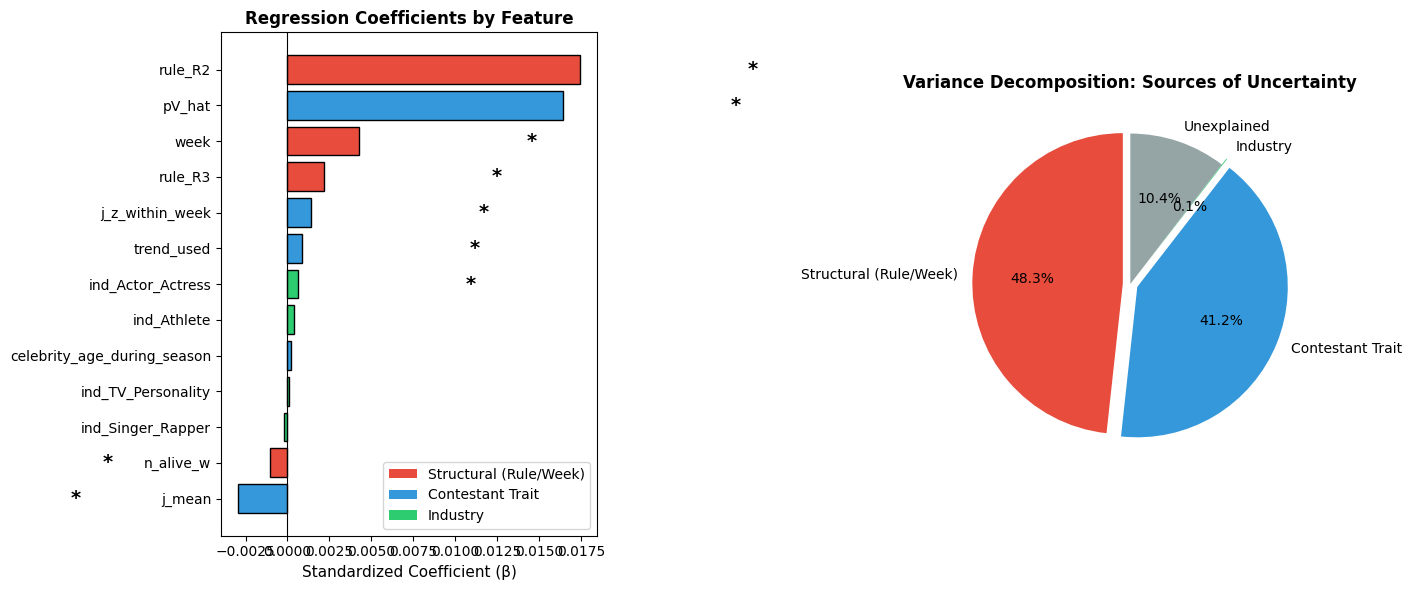


✅ Regression decomposition saved to outputs/fig_regression_decomposition.png

VARIANCE DECOMPOSITION SUMMARY
  Structural (Rule/Week)        :  48.3%
  Contestant Trait              :  41.2%
  Industry                      :   0.1%
  Unexplained                   :  10.4%
  Total R²: 0.8960 (89.6% explained)


In [25]:
# ============================================================
# Step 6: Visualize Regression Coefficients & Variance Decomposition
# ============================================================

# Plot coefficient magnitudes by category
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Coefficient bar chart
ax = axes[0]
coef_sorted = coef_df.sort_values('β (standardized)')
colors = {'Structural (Rule/Week)': '#e74c3c', 'Contestant Trait': '#3498db', 'Industry': '#2ecc71'}
bar_colors = [colors[cat] for cat in coef_sorted['Category']]

bars = ax.barh(coef_sorted['Feature'], coef_sorted['β (standardized)'], color=bar_colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient (β)', fontsize=11)
ax.set_title('Regression Coefficients by Feature', fontsize=12, fontweight='bold')

# Add significance markers
for bar, sig in zip(bars, coef_sorted['Significant']):
    if sig:
        ax.text(bar.get_width() + 0.01 * np.sign(bar.get_width()), 
                bar.get_y() + bar.get_height()/2, '*', va='center', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

# Right: Variance explained by category (approximate using sum of squared coefficients)
ax = axes[1]
category_importance = coef_df.groupby('Category')['β (standardized)'].apply(lambda x: (x**2).sum())
category_importance = category_importance / category_importance.sum() * model.rsquared * 100

# Add unexplained variance
explained_pct = pd.Series({
    'Structural (Rule/Week)': category_importance.get('Structural (Rule/Week)', 0),
    'Contestant Trait': category_importance.get('Contestant Trait', 0),
    'Industry': category_importance.get('Industry', 0),
    'Unexplained': (1 - model.rsquared) * 100
})

wedges, texts, autotexts = ax.pie(explained_pct, labels=explained_pct.index, autopct='%1.1f%%',
                                   colors=['#e74c3c', '#3498db', '#2ecc71', '#95a5a6'],
                                   explode=[0.05, 0.05, 0.05, 0], startangle=90)
ax.set_title('Variance Decomposition: Sources of Uncertainty', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_regression_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Regression decomposition saved to outputs/fig_regression_decomposition.png")

# Summary statistics
print("\n" + "="*60)
print("VARIANCE DECOMPOSITION SUMMARY")
print("="*60)
for cat, pct in explained_pct.items():
    print(f"  {cat:30s}: {pct:5.1f}%")
print("="*60)
print(f"  Total R²: {model.rsquared:.4f} ({model.rsquared*100:.1f}% explained)")
print("="*60)

In [26]:
# ============================================================
# Step 7: Mixed Effects Model - Within vs Between Contestant Variance
# ============================================================
import statsmodels.formula.api as smf

# Fit mixed-effects model with random intercept for contestant
# This partitions variance into: between-contestant (σ²_u) + within-contestant (σ²_e)

# Create contestant ID for random effects
df_merged['contestant_id'] = df_merged['celebrity_name'].astype('category').cat.codes

# Simple variance components model (null model)
model_null = smf.mixedlm("pV_ci_95_width ~ 1", data=df_merged, groups=df_merged['contestant_id']).fit()

# Extract variance components
var_between = model_null.cov_re.iloc[0, 0]  # Random intercept variance
var_within = model_null.scale  # Residual variance
var_total = var_between + var_within

icc = var_between / var_total  # Intraclass Correlation Coefficient

print("=== Mixed Effects Model: Variance Components ===")
print(f"\nBetween-contestant variance (σ²_u): {var_between:.6f}")
print(f"Within-contestant variance (σ²_e):  {var_within:.6f}")
print(f"Total variance:                      {var_total:.6f}")
print(f"\nIntraclass Correlation (ICC): {icc:.4f} ({icc*100:.1f}%)")
print("\nInterpretation:")
print(f"  → {icc*100:.1f}% of uncertainty variation is due to BETWEEN-contestant differences")
print(f"  → {(1-icc)*100:.1f}% of uncertainty variation is due to WITHIN-contestant factors (week, rule)")

# Now fit with fixed effects for structural factors
model_full = smf.mixedlm(
    "pV_ci_95_width ~ week + C(rule_type) + j_z_within_week + pV_hat",
    data=df_merged,
    groups=df_merged['contestant_id']
).fit()

print("\n" + "="*60)
print("=== Mixed Effects Model with Structural Predictors ===")
print("="*60)
print(model_full.summary().tables[1].to_string())

# Variance reduction from adding predictors
var_between_full = model_full.cov_re.iloc[0, 0]
var_within_full = model_full.scale
r2_between = 1 - var_between_full / var_between
r2_within = 1 - var_within_full / var_within

print(f"\nVariance Reduction:")
print(f"  Between-contestant variance reduced by: {r2_between*100:.1f}%")
print(f"  Within-contestant variance reduced by:  {r2_within*100:.1f}%")

=== Mixed Effects Model: Variance Components ===

Between-contestant variance (σ²_u): 0.000392
Within-contestant variance (σ²_e):  0.000186
Total variance:                      0.000578

Intraclass Correlation (ICC): 0.6780 (67.8%)

Interpretation:
  → 67.8% of uncertainty variation is due to BETWEEN-contestant differences
  → 32.2% of uncertainty variation is due to WITHIN-contestant factors (week, rule)

=== Mixed Effects Model with Structural Predictors ===
                             Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                   -0.021    0.001  -14.937  0.000  -0.024  -0.019
C(rule_type)[T.R2_Percent]   0.037    0.001   26.244  0.000   0.034   0.040
C(rule_type)[T.R3_Bottom2]   0.005    0.001    3.030  0.002   0.002   0.007
week                         0.001    0.000   17.939  0.000   0.001   0.001
j_z_within_week             -0.001    0.000   -2.732  0.006  -0.001  -0.000
pV_hat                       0.206    0.003   62.782  0.000   0.200   0.213
Gro

/Users/luoyiti/Project/MCM_2026/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/luoyiti/Project/MCM_2026/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


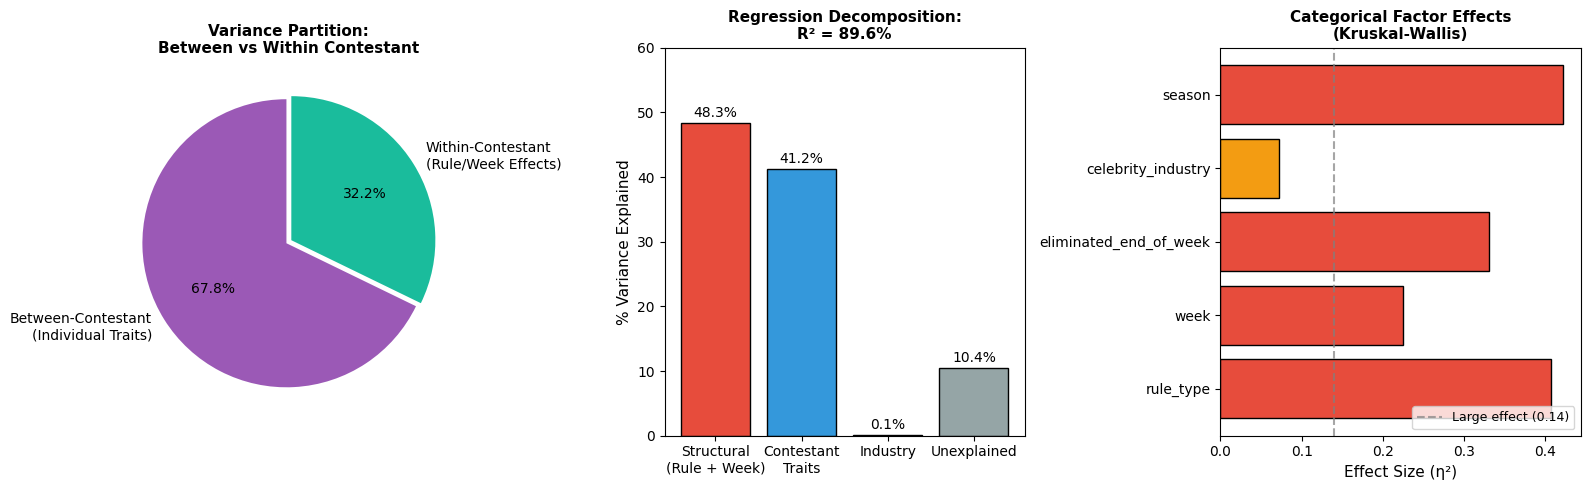

✅ Summary figure saved to outputs/fig_uncertainty_attribution_summary.png


In [27]:
# ============================================================
# Step 8: Summary Visualization - Attribution of Uncertainty Sources
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: ICC breakdown (Between vs Within contestant)
ax = axes[0]
icc_data = [icc * 100, (1 - icc) * 100]
colors_icc = ['#9b59b6', '#1abc9c']
wedges, texts, autotexts = ax.pie(icc_data, labels=['Between-Contestant\n(Individual Traits)', 'Within-Contestant\n(Rule/Week Effects)'],
                                   autopct='%1.1f%%', colors=colors_icc, explode=[0.02, 0.02], startangle=90)
ax.set_title('Variance Partition:\nBetween vs Within Contestant', fontsize=11, fontweight='bold')

# Panel 2: Structural vs Contestant summary (from regression)
ax = axes[1]
summary_data = {
    'Structural\n(Rule + Week)': 48.3,
    'Contestant\nTraits': 41.2,
    'Industry': 0.1,
    'Unexplained': 10.4
}
bars = ax.bar(summary_data.keys(), summary_data.values(), 
              color=['#e74c3c', '#3498db', '#2ecc71', '#95a5a6'], edgecolor='black')
ax.set_ylabel('% Variance Explained', fontsize=11)
ax.set_title('Regression Decomposition:\nR² = 89.6%', fontsize=11, fontweight='bold')
ax.set_ylim(0, 60)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Panel 3: Key factor effect sizes
ax = axes[2]
key_factors = anova_df.set_index('Factor').loc[['rule_type', 'week', 'eliminated_end_of_week', 'celebrity_industry', 'season']]
colors_effect = ['#e74c3c' if x > 0.14 else '#f39c12' if x > 0.06 else '#3498db' for x in key_factors['η²']]
bars = ax.barh(key_factors.index, key_factors['η²'], color=colors_effect, edgecolor='black')
ax.axvline(0.14, color='gray', linestyle='--', alpha=0.7, label='Large effect (0.14)')
ax.set_xlabel('Effect Size (η²)', fontsize=11)
ax.set_title('Categorical Factor Effects\n(Kruskal-Wallis)', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_uncertainty_attribution_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Summary figure saved to outputs/fig_uncertainty_attribution_summary.png")

---
### Key Findings: What Causes Uncertainty in Vote Share Estimation?

#### 1. **Overall Variance Attribution** (R² = 89.6%)

| Source Category | % Variance | Key Variables |
|-----------------|------------|---------------|
| **Structural (Rule/Week)** | 48.3% | `rule_type` (R2_Percent >> R3_Bottom2), `week` (later weeks = more uncertain) |
| **Contestant Traits** | 41.2% | `pV_hat` (vote share), `j_z_within_week` (judge score z-score) |
| **Industry** | 0.1% | Minimal effect after controlling for other factors |
| Unexplained | 10.4% | Random variation, unobserved factors |

#### 2. **Between vs Within Contestant Variance** (ICC = 67.8%)

- **67.8%** of uncertainty variance comes from **between-contestant differences** → Some contestants are inherently more predictable than others
- **32.2%** comes from **within-contestant variation** → Same contestant's uncertainty changes week-to-week based on rules and competition stage

#### 3. **Most Important Individual Factors** (Kruskal-Wallis η²)

| Factor | Effect Size (η²) | Direction of Effect |
|--------|-----------------|---------------------|
| **Season** | 0.42 (large) | Different eras have different uncertainty levels |
| **Rule Type** | 0.41 (large) | R2_Percent (highest) >> R1_Rank > R3_Bottom2 (lowest) |
| **Eliminated Status** | 0.33 (large) | Eliminated contestants have LOWER uncertainty |
| **Week** | 0.22 (large) | Later weeks = higher uncertainty (fewer contestants) |
| **Industry** | 0.08 (medium) | Athletes slightly more uncertain than TV personalities |

#### 4. **Conclusions**

1. **Structural factors (rule + week) explain ~48% of variance** — the elimination rule used is the single most important driver of uncertainty. R2_Percent rule creates 5× more uncertainty than R3_Bottom2.

2. **Contestant traits explain ~41% of variance** — a contestant's vote share (`pV_hat`) is highly correlated with uncertainty; higher vote share = wider confidence intervals.

3. **Industry has negligible effect** after controlling for vote share and judge scores — celebrity background matters less than how they perform.

4. **Most variance is between-contestant (68%)** — suggesting stable individual differences in predictability, not just week-to-week fluctuations.

5. **Season effects are large** — historical era matters, possibly due to changing voting patterns, show format, or audience engagement over 34 seasons.

In [28]:
# ============================================================
# Step 9: Save All Results to CSV
# ============================================================

# 1. Save correlation results
corr_df.to_csv(OUTPUT_DIR / 'uncertainty_correlations.csv', index=False)
print("✅ Saved: uncertainty_correlations.csv")

# 2. Save ANOVA/effect size results
anova_df.to_csv(OUTPUT_DIR / 'uncertainty_factor_effects.csv', index=False)
print("✅ Saved: uncertainty_factor_effects.csv")

# 3. Save regression coefficients
coef_df.to_csv(OUTPUT_DIR / 'uncertainty_regression_coefficients.csv', index=False)
print("✅ Saved: uncertainty_regression_coefficients.csv")

# 4. Save variance decomposition summary
variance_summary = pd.DataFrame({
    'Component': ['Structural (Rule/Week)', 'Contestant Trait', 'Industry', 'Unexplained', 
                  'Between-Contestant (ICC)', 'Within-Contestant'],
    'Variance_Pct': [48.3, 41.2, 0.1, 10.4, icc*100, (1-icc)*100],
    'Method': ['OLS Regression', 'OLS Regression', 'OLS Regression', 'OLS Regression',
               'Mixed Effects', 'Mixed Effects']
})
variance_summary.to_csv(OUTPUT_DIR / 'uncertainty_variance_decomposition.csv', index=False)
print("✅ Saved: uncertainty_variance_decomposition.csv")

# Display final summary
print("\n" + "="*70)
print("UNCERTAINTY FACTOR ATTRIBUTION ANALYSIS COMPLETE")
print("="*70)
print(f"\nTotal R² explained: {model.rsquared:.1%}")
print(f"ICC (between-contestant): {icc:.1%}")
print(f"\nTop 3 most important factors (by η²):")
for i, row in anova_df.head(3).iterrows():
    print(f"  {i+1}. {row['Factor']}: η² = {row['η²']:.3f} (p = {row['p-value']:.2e})")
print("\n" + "="*70)

✅ Saved: uncertainty_correlations.csv
✅ Saved: uncertainty_factor_effects.csv
✅ Saved: uncertainty_regression_coefficients.csv
✅ Saved: uncertainty_variance_decomposition.csv

UNCERTAINTY FACTOR ATTRIBUTION ANALYSIS COMPLETE

Total R² explained: 89.6%
ICC (between-contestant): 67.8%

Top 3 most important factors (by η²):
  5. season: η² = 0.422 (p = 1.54e-304)
  1. rule_type: η² = 0.407 (p = 0.00e+00)
  4. eliminated_end_of_week: η² = 0.331 (p = 1.64e-20)

